# Part 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
sns.set_style("whitegrid")

print("All packages loaded successfully!")

All packages loaded successfully!


In [2]:
trans = pd.read_excel("Original_data_translatome SARS-CoV-2 infection timecourse.xlsx")

# Strip any invisible whitespace from column names
trans.columns = trans.columns.str.strip()

print(f"Translatome dataset: {trans.shape[0]} rows x {trans.shape[1]} columns")
print("\nFirst few columns:", trans.columns[:5].tolist())
print("\nPreview:")
trans.head(3)

Translatome dataset: 2715 rows x 26 columns

First few columns: ['Accession', 'Gene Symbol', 'Control 2h_1', 'Control 2h_2', 'Control 2h_3']

Preview:


,Accession,Gene Symbol,Control 2h_1,Control 2h_2,Control 2h_3,Control 6h_1,Control 6h_2,Control 6h_3,Control 10h_1,Control 10h_2,...,Virus 2h_3,Virus 6h_1,Virus 6h_2,Virus 6h_3,Virus 10h_1,Virus 10h_2,Virus 10h_3,Virus 24h_1,Virus 24h_2,Virus 24h_3
0,P02771,AFP,981.258045,1183.175939,1440.326216,1205.249514,1338.177985,1286.491071,925.301366,887.729721,...,1368.807115,1080.088342,834.725899,1137.064316,801.446269,879.117742,557.265750,NaN,49.176430,74.536415
1,P07148,FABP1,1305.009230,1280.049817,1210.800481,1154.277967,1100.749505,923.312640,773.390082,751.006613,...,1124.476848,925.532470,823.233662,749.227122,717.087658,652.713592,289.565529,183.254575,90.028324,NaN
2,P09327,VIL1,839.773511,1031.083693,972.479005,860.300797,988.012894,962.336146,753.439585,913.424345,...,944.399105,688.074439,777.868392,848.898137,504.955960,562.044979,447.058216,90.977274,89.112956,73.822910


In [3]:
timepoints   = ['2h', '6h', '10h', '24h']
replicates   = [1, 2, 3]
control_cols = [f"Control {tp}_{r}" for tp in timepoints for r in replicates]
virus_cols   = [f"Virus {tp}_{r}"   for tp in timepoints for r in replicates]
sample_cols  = control_cols + virus_cols

print(f"Control columns ({len(control_cols)}): {control_cols[:3]} ...")
print(f"Virus columns   ({len(virus_cols)}):   {virus_cols[:3]} ...")

Control columns (12): ['Control 2h_1', 'Control 2h_2', 'Control 2h_3'] ...
Virus columns   (12):   ['Virus 2h_1', 'Virus 2h_2', 'Virus 2h_3'] ...


### Task 1: Total proteins detected

In [4]:
print(f"Total proteins in dataset: {len(trans)}")

Total proteins in dataset: 2715


###  Task 2 & 3: Proteins detected and missing per sample

In [5]:
sample_counts    = trans[sample_cols].notna().sum(axis=0)
sample_counts_NA = trans[sample_cols].isna().sum(axis=0)

# Combine into one dataframe for stacked bar
sample_counts_df = pd.DataFrame({
    "Detected":     sample_counts,
    "Not Detected": sample_counts_NA
})

print("Proteins detected / missing per sample:")
print(sample_counts_df.to_string())

Proteins detected / missing per sample:
               Detected  Not Detected
Control 2h_1       1490          1225
Control 2h_2       1606          1109
Control 2h_3       1507          1208
Control 6h_1       1611          1104
Control 6h_2       1671          1044
Control 6h_3       1633          1082
Control 10h_1      1614          1101
Control 10h_2      1816           899
Control 10h_3      1719           996
Control 24h_1      1579          1136
Control 24h_2      1702          1013
Control 24h_3      1671          1044
Virus 2h_1         1443          1272
Virus 2h_2         1602          1113
Virus 2h_3         1494          1221
Virus 6h_1         1553          1162
Virus 6h_2         1656          1059
Virus 6h_3         1603          1112
Virus 10h_1        1430          1285
Virus 10h_2        1527          1188
Virus 10h_3        1478          1237
Virus 24h_1        1279          1436
Virus 24h_2        1496          1219
Virus 24h_3        1488          1227


### Plot: Stacked bar of detected vs missing per sample

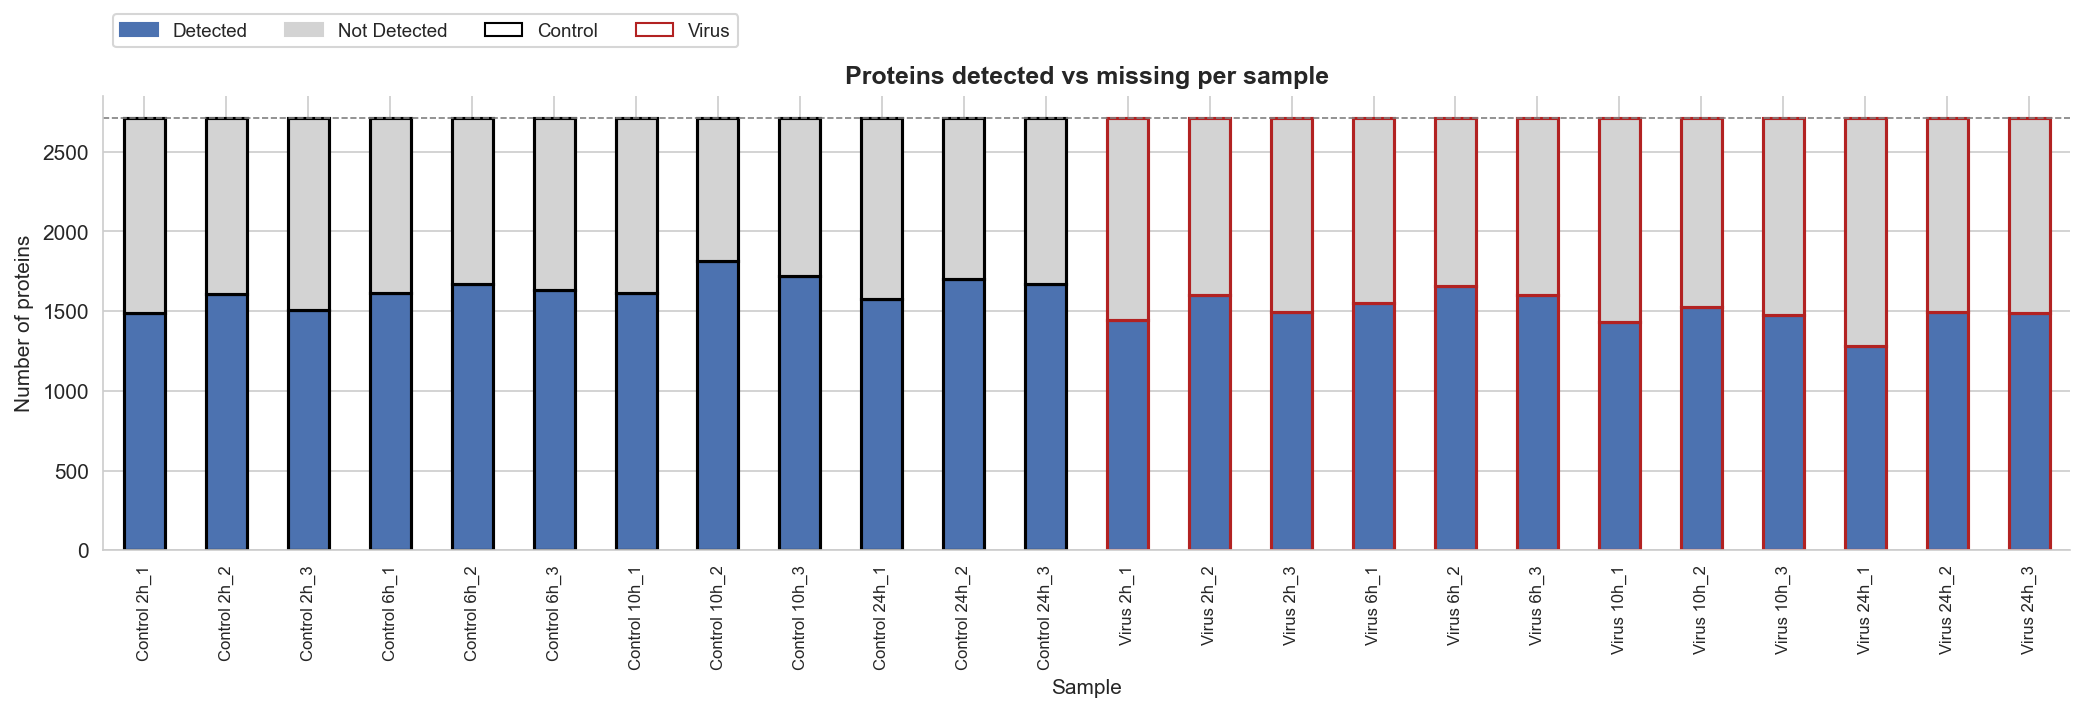

In [6]:
colours = ["#4C72B0", "lightgrey"]   # Detected, Not Detected

# Edge colours to distinguish Control vs Virus
edge_colours = [
    "black" if "Control" in col else "firebrick"
    for col in sample_counts_df.index
] * 2   # *2 because stacked = two bar segments per sample

fig, ax = plt.subplots(figsize=(14, 5))
sample_counts_df.plot(kind='bar', stacked=True,
                      color=colours, linewidth=1.5, ax=ax)

# Apply edge colours to each bar patch
for bar, edge in zip(ax.patches, edge_colours):
    bar.set_edgecolor(edge)

# Custom legend entries
legend_handles = [
    mpatches.Patch(color="#4C72B0",    label="Detected"),
    mpatches.Patch(color="lightgrey",  label="Not Detected"),
    mpatches.Patch(facecolor="white",  edgecolor="black",     label="Control"),
    mpatches.Patch(facecolor="white",  edgecolor="firebrick", label="Virus"),
]
ax.legend(handles=legend_handles, loc='upper left',
          bbox_to_anchor=(0, 1.2), ncol=4, fontsize=9)

ax.set_ylabel("Number of proteins", fontsize=10)
ax.set_xlabel("Sample", fontsize=10)
ax.set_title("Proteins detected vs missing per sample",
             fontsize=12, fontweight='bold')
ax.set_xticklabels(sample_counts_df.index, rotation=90, fontsize=8)
ax.axhline(y=len(trans), linestyle='--', color='grey',
           linewidth=0.8, label=f"Total = {len(trans)}")
sns.despine()
plt.tight_layout()
plt.savefig('W11_T2_T3_detected_per_sample.png', bbox_inches='tight')
plt.show()

The Control/Virus edge colour distinction works well, and we can clearly see the ~40-45% missingness is consistent across all samples.

### Task 4: Detection per protein

In [7]:
detection_per_protein = trans[sample_cols].notna().sum(axis=1)

print("Detection summary per protein:")
print(detection_per_protein.describe())
print(f"\nProteins detected in ALL 24 samples: {(detection_per_protein == 24).sum()}")
print(f"Proteins detected in NO  samples:    {(detection_per_protein == 0).sum()}")

Detection summary per protein:
count    2715.000000
mean       13.874033
std         8.511835
min         0.000000
25%         6.000000
50%        15.000000
75%        22.000000
max        24.000000
dtype: float64

Proteins detected in ALL 24 samples: 466
Proteins detected in NO  samples:    286


466 proteins detected in all 24 samples, 286 detected in none. The mean of ~14 samples out of 24 confirms the heavy missingness.

### Plot: Distribution of detection across proteins

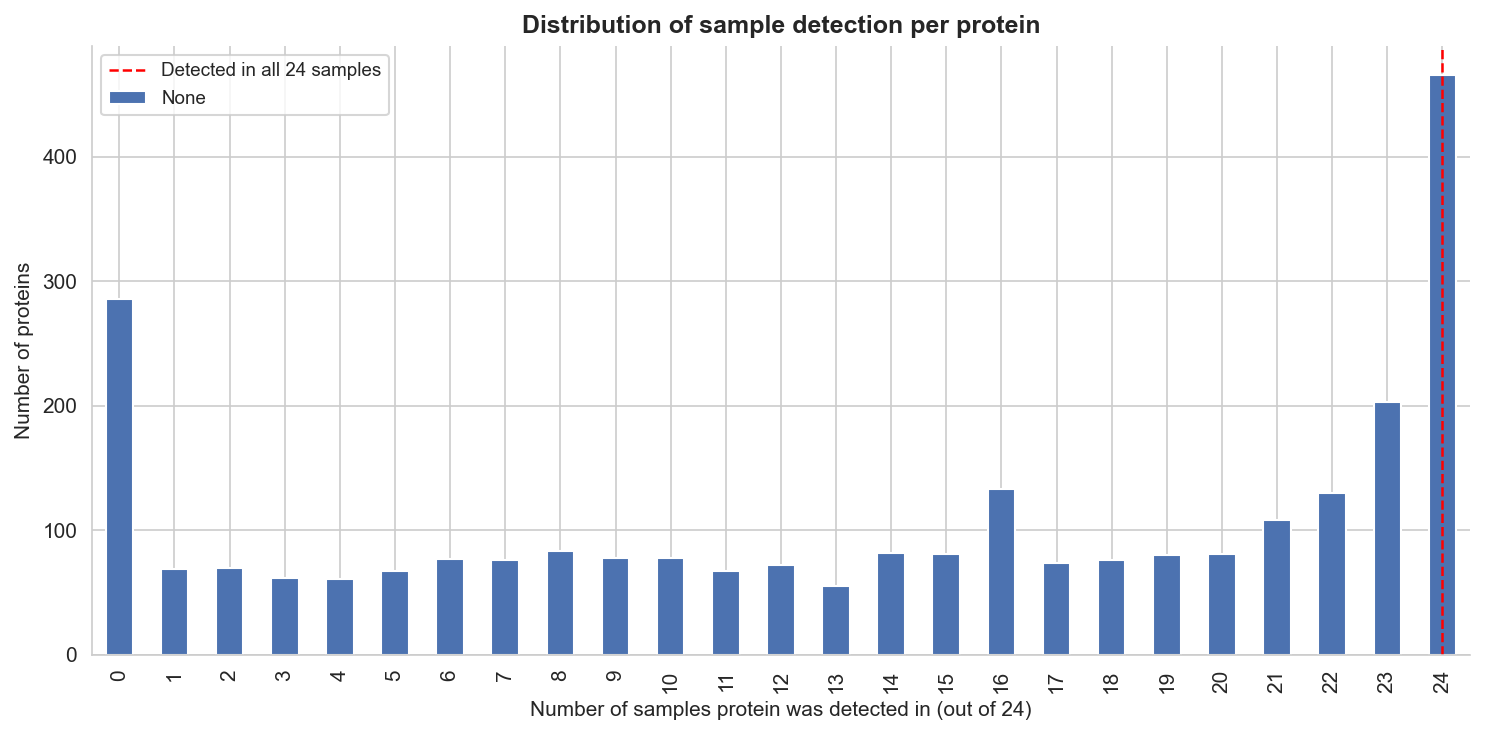

In [8]:
distribution = detection_per_protein.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
distribution.plot(kind='bar', color='#4C72B0', edgecolor='white', ax=ax)
ax.axvline(x=distribution.index.tolist().index(24),
           linestyle='--', color='red', linewidth=1.2,
           label='Detected in all 24 samples')
ax.set_xlabel("Number of samples protein was detected in (out of 24)", fontsize=10)
ax.set_ylabel("Number of proteins", fontsize=10)
ax.set_title("Distribution of sample detection per protein",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('W11_T4_detection_distribution.png', bbox_inches='tight')
plt.show()

The two peaks at 0 and 24 are the most important feature here. The large bar at 0 (286 proteins never detected) and the peak at 24 (466 always detected) with a fairly flat distribution in between is exactly the MNAR pattern — proteins are either consistently detectable or consistently missing, not randomly missing.

### Task 5: Heatmap of detection

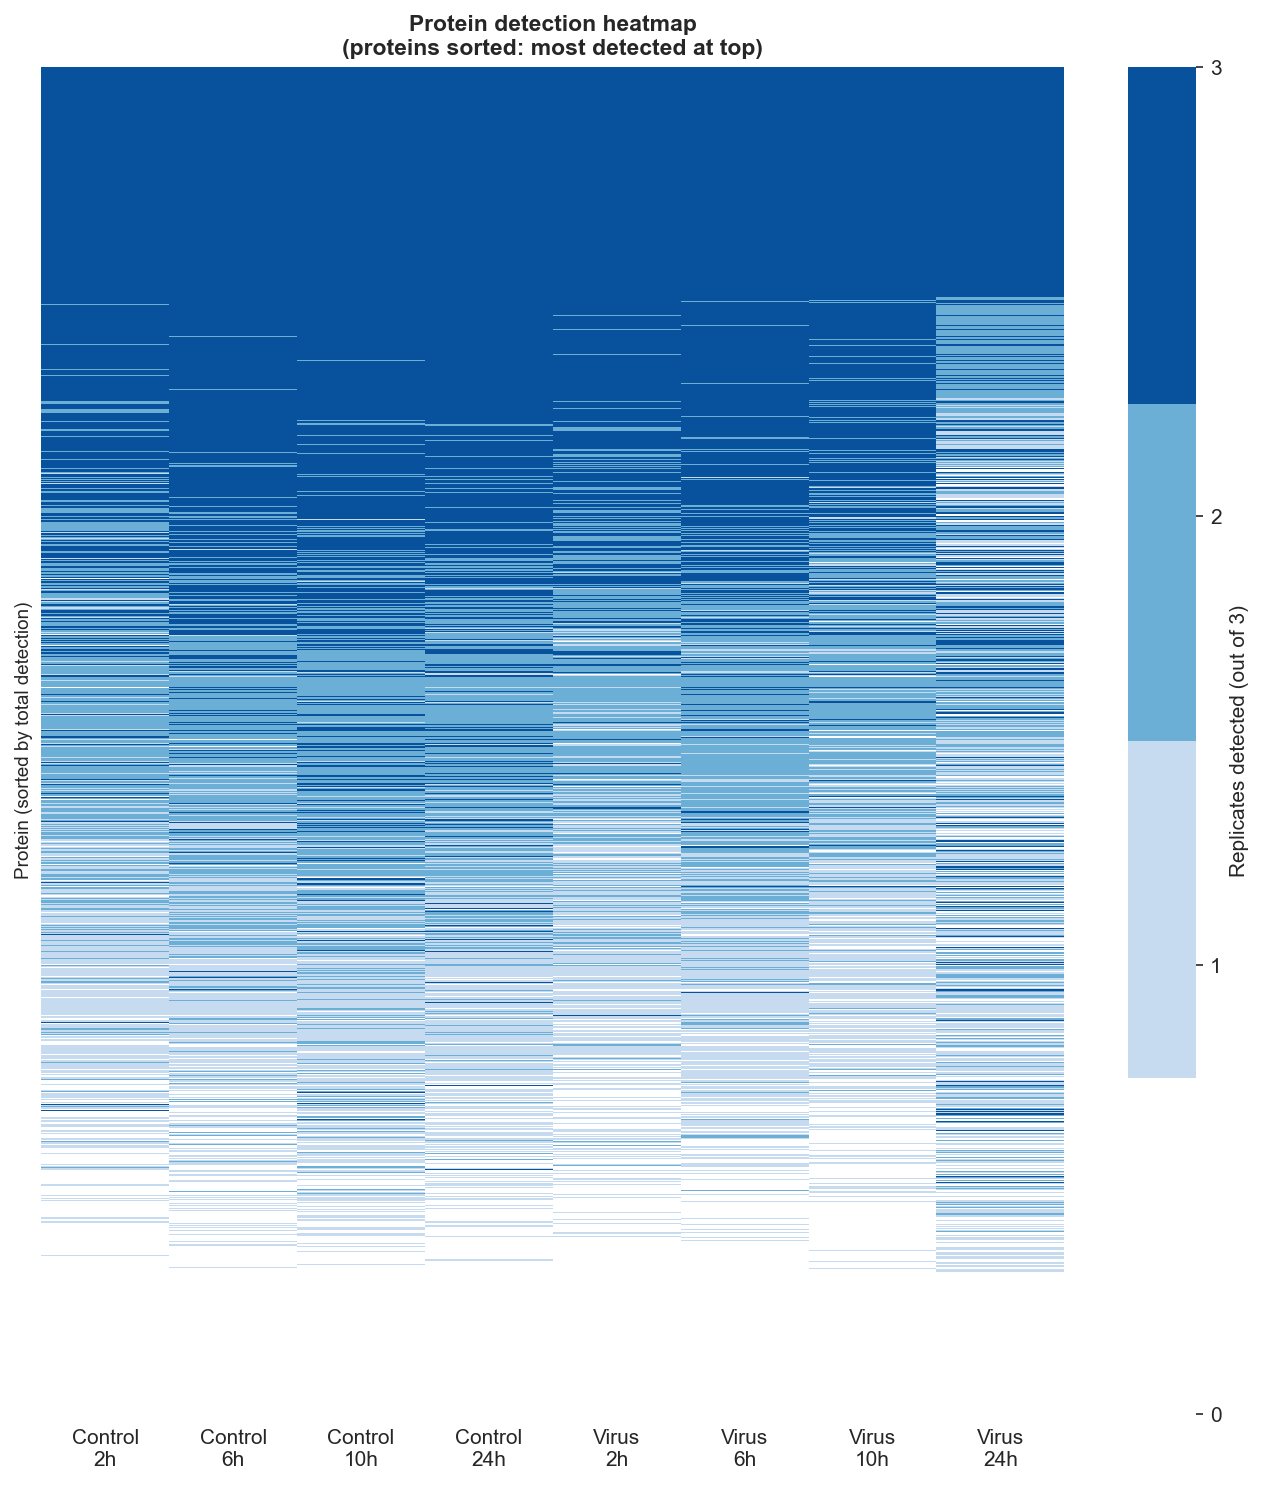

In [9]:
# Build detection matrix: replicates detected per protein per condition/timepoint
missing_long = trans[['Accession'] + sample_cols].melt(
    id_vars   = 'Accession',
    var_name  = 'Sample',
    value_name= 'Intensity'
)
missing_long['Detected']  = missing_long['Intensity'].notna()
missing_long['Condition'] = missing_long['Sample'].apply(
    lambda x: 'Control' if 'Control' in x else 'Virus'
)
missing_long['Timepoint'] = pd.Categorical(
    missing_long['Sample'].str.extract(r'(\d+h)')[0],
    categories=['2h', '6h', '10h', '24h'], ordered=True
)
missing_long['Sample_group'] = pd.Categorical(
    missing_long['Condition'] + '\n' + missing_long['Timepoint'].astype(str),
    categories=[
        'Control\n2h', 'Control\n6h', 'Control\n10h', 'Control\n24h',
        'Virus\n2h',   'Virus\n6h',   'Virus\n10h',   'Virus\n24h'
    ], ordered=True
)

# Count replicates detected per protein per group
det_summary = (
    missing_long
    .groupby(['Accession', 'Sample_group'], observed=True)['Detected']
    .sum()
    .reset_index(name='n_detected')
)

# Sort proteins by total detection (most detected at top)
protein_order = (
    det_summary.groupby('Accession')['n_detected']
    .sum()
    .sort_values(ascending=False)
    .index.tolist()
)
det_summary['Accession'] = pd.Categorical(
    det_summary['Accession'], categories=protein_order, ordered=True
)

# Pivot for heatmap
heatmap_pivot = det_summary.pivot(
    index='Accession', columns='Sample_group', values='n_detected'
)

fig, ax = plt.subplots(figsize=(9, 10))
cmap = sns.color_palette(["white", "#C6DBEF", "#6BAED6", "#08519C"])
sns.heatmap(
    heatmap_pivot,
    cmap=cmap, vmin=0, vmax=3,
    ax=ax, linewidths=0,
    cbar_kws={'label': 'Replicates detected (out of 3)',
              'ticks': [0, 1, 2, 3]}
)
ax.set_yticks([])
ax.set_ylabel("Protein (sorted by total detection)", fontsize=9)
ax.set_xlabel("")
ax.set_title("Protein detection heatmap\n(proteins sorted: most detected at top)",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('W11_T5_detection_heatmap.png', bbox_inches='tight')
plt.show()

The gradient from dark blue at the top to white at the bottom perfectly visualises the sorted detection. We can also see the Virus 24h column has a noticeably different pattern on the right side, which is biologically interesting.

### MNAR scatter plot

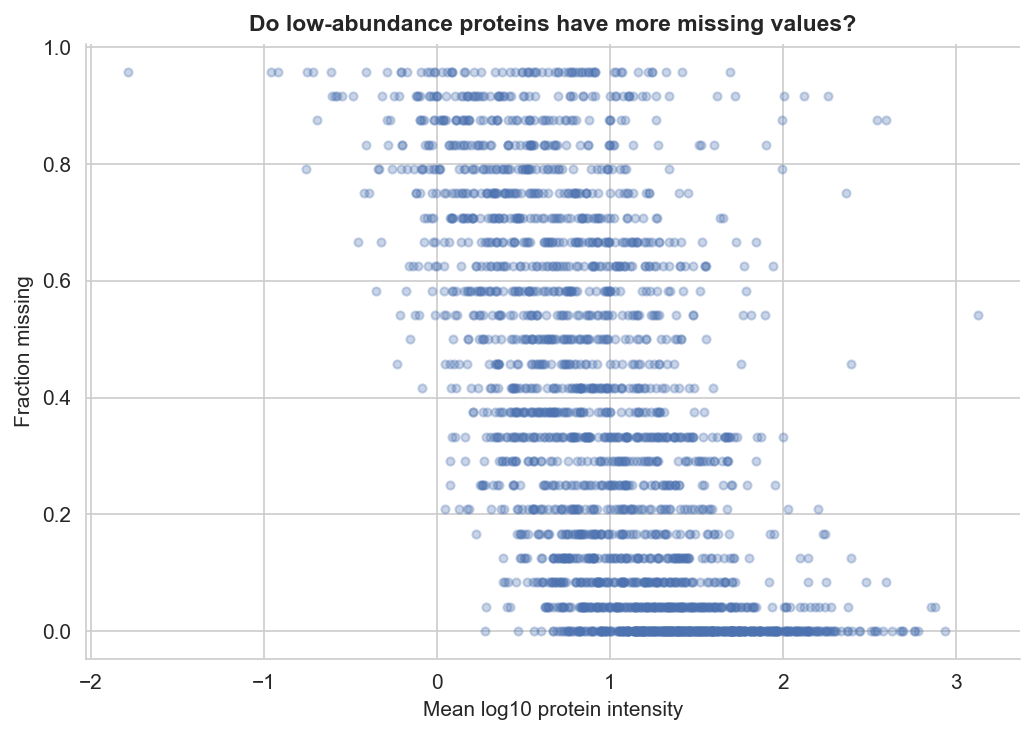

In [10]:
# Does missingness correlate with low abundance? → MNAR pattern
intensity_data = trans[sample_cols].copy()
intensity_data_log = np.log10(intensity_data.where(intensity_data > 0))

protein_stats = pd.DataFrame({
    'mean_log10':      intensity_data_log.mean(axis=1, skipna=True),
    'frac_missing':    intensity_data.isna().mean(axis=1)
})

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    protein_stats['mean_log10'],
    protein_stats['frac_missing'],
    alpha=0.3, s=15, color='#4C72B0'
)
ax.set_xlabel("Mean log10 protein intensity", fontsize=10)
ax.set_ylabel("Fraction missing", fontsize=10)
ax.set_title("Do low-abundance proteins have more missing values?",
             fontsize=11, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('W11_T6_MNAR_scatter.png', bbox_inches='tight')
plt.show()

The triangular shape (high missingness only at low-to-mid intensity, low missingness at high intensity) is the hallmark MNAR signature — proteins below the detection threshold are systematically missing, not randomly missing.

## Discussion

### Task 1 — Total proteins detected
A total of 2,715 proteins were quantified in the translatome dataset,
compared to ~6,380 in the proteome dataset from Week 10. This is roughly
half the number, which is expected because the translatome measures only
NEWLY SYNTHESISED proteins (actively being translated at the time of
measurement), whereas the proteome measures ALL proteins present in the
cell including long-lived stable proteins.

### Tasks 2 & 3 — Proteins detected and missing per sample
Tasks 2 and 3 are visualised together in a single stacked bar chart,
where the blue portion represents detected proteins and the grey portion
represents missing values for each sample. This allows direct comparison
of detection and missingness in one view, with black outlines indicating
Control samples and red outlines indicating Virus samples.

Each sample detected between ~1,279 and ~1,816 proteins out of 2,715
total. Key observations:
+ No sample detected all 2,715 proteins — all bars fall well below
  the dashed reference line at 2,715
+ Control samples generally detected slightly more proteins than Virus
  samples, particularly at 10h and 24h, visible from the taller blue
  portions in the Control half of the plot
+ Virus 24h_1 detected the fewest proteins (~1,279), suggesting either
  a technical issue or a biological effect of late infection on host
  protein synthesis
+ Noticeable variability between replicates within the same condition
  and timepoint is observed (e.g. Control 10h ranges from ~1,614 to
  ~1,816)

Each sample has between 899 and 1,436 missing values out of 2,715
total proteins, meaning approximately 33–53% of values are missing per
sample — an extremely high level of missingness. The grey portions
directly reflect the inverse of detection: samples with fewer detected
proteins have correspondingly larger grey sections. Virus 24h samples
show the most missing values, particularly Virus 24h_1 (1,436 missing).

### Task 4 — Detection per protein
The bar chart of detection per protein reveals a bimodal distribution:
- **Large bar at 0**: 286 proteins were detected in NO samples at all.
  These are proteins present in the reference database but never
  detected by the mass spectrometer in any sample.
- **Flat middle section (1–22 samples)**: many proteins are detected
  inconsistently across samples, with roughly 60–85 proteins at each
  detection level.
- **Large bar at 24**: 466 proteins were detected in ALL 24 samples.
  These are the most reliably and consistently detected proteins.
- Only 466/2,715 (17%) proteins were detected in every single sample,
  highlighting how sparse the data are overall.

### Task 5 — Detection heatmap
The heatmap shows the number of replicates (out of 3) in which each
protein was detected, across all 8 condition/timepoint combinations.
Proteins are sorted by total detection with the most consistently
detected proteins at the top. Colours represent discrete detection
levels: white (0 replicates), light blue (1), medium blue (2), dark
blue (3 — all replicates detected).

Three distinct zones are visible:

**Top zone (dark blue — consistently detected):** Proteins detected in
all 3 replicates across most or all conditions and timepoints. These are
the most abundant and reliably quantified proteins, corresponding to the
466 proteins detected in all 24 samples seen in the histogram.

**Middle zone (mixed colours — inconsistently detected):** Proteins
detected in only 1 or 2 replicates in some conditions. The same protein
may be detected in all replicates at one timepoint but missing at
another. This inconsistency makes statistical analysis unreliable for
these proteins without imputation or filtering.

**Bottom zone (white — rarely or never detected):** Proteins detected
in very few or no samples, corresponding to the 286 proteins at x=0 in
the histogram. These fall below the detection limit of the mass
spectrometer in this experiment and cannot be used for downstream
analysis.

**Key observation — Virus 24h column:** The Virus 24h column (far
right) is notably lighter than all other columns, even compared to
other Virus timepoints. The dark blue zone at the top is visibly
smaller than in the Control columns, and lighter colours extend further
down. This confirms that the 24h virus samples have the most missing
values and fewest detected proteins, which could reflect:
- Technical variability specific to those samples
- A genuine biological effect of late-stage infection causing active
  suppression of host protein synthesis during peak viral replication

The clear gradient from top (dark blue) to bottom (white) confirms that
missingness is largely related to protein abundance — consistently
abundant proteins are reliably detected while low-abundance proteins are
sporadically detected or missed entirely.

### Task 6 — Does missingness represent a problem?

**Yes — missingness is a serious problem in this dataset for several
reasons:**

**1. Statistical testing:** To perform a t-test comparing Control vs
Virus, we need values in all replicates. With ~40–50% missing values
per sample, a large proportion of proteins cannot be statistically
tested reliably, significantly limiting the number of proteins we can
draw conclusions from.

**2. Fold change calculation:** Calculating log2(Virus/Control) requires
values in both conditions. Missing values in either condition make the
ratio impossible to calculate or unreliable.

**3. Bias — Missing Not At Random (MNAR):** As demonstrated in the MNAR
scatter plot, missing values are NOT random. We can clearly observe that
proteins with lower mean log10 intensity have a higher fraction of
missing values, forming a triangular pattern where high missingness is
only seen at low-to-mid intensity but never at high intensity. This
confirms the MNAR pattern — proteins fall below the mass spectrometer
detection limit systematically based on their abundance. This creates
a bias problem: a protein appearing "missing" in virus samples could
either be genuinely down-regulated (truly absent) or simply below the
detection limit by chance. These two scenarios cannot be distinguished
without additional information.

**4. Reproducibility:** High variability in detection between replicates
within the same condition (e.g. Control 10h: 1,614 vs 1,816 proteins
detected) reduces confidence in the results and suggests inconsistent
measurement.

### Task 7 — Strategies to deal with missingness

**Strategy 1 — Filtering (most conservative):** We can remove proteins
with too many missing values before analysis. For example, keeping only
proteins detected in at least 2 out of 3 replicates in at least one
condition. This reduces the dataset size but ensures that only reliably
quantified proteins are included in downstream analysis.

**Strategy 2 — Imputation (most common in proteomics):** We can replace
missing values with estimated values. Common approaches include:
- Minimum value imputation: replace NA with the minimum detected value
  in that sample (assumes missing = low abundance)
- Gaussian imputation: replace NA with a random value drawn from the
  lower end of the intensity distribution, as implemented in Perseus
  software
- KNN imputation: estimate the missing value based on the expression
  patterns of similar proteins in the dataset

**Strategy 3 — Statistical methods that handle missing data:** We can
use statistical frameworks designed for incomplete data, such as limma
(linear models for microarray/proteomics data), which handles missing
values more robustly than simple t-tests.

**Strategy 4 — Presence/absence analysis:** Rather than treating
missingness purely as a problem, we can treat it as biological
information. A protein consistently absent in virus-infected samples
but present in control samples (or vice versa) could itself represent
a biologically meaningful finding, reflecting genuine regulation rather
than a technical artefact.

# Part 2

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
sns.set_style("whitegrid")
print("All packages loaded successfully!")

All packages loaded successfully!


In [12]:
# Load imputed translatome (CSV)
trans_imp = pd.read_csv(
    "Imputed_translatome SARS-CoV-2 infection timecourse.csv"
)
trans_imp.columns = trans_imp.columns.str.strip()
# Rename first column to Accession if needed
trans_imp = trans_imp.rename(columns={trans_imp.columns[0]: 'Accession'})

# Load SARS-CoV-2 reference
sars_ref = pd.read_excel("SARS-CoV-2 proteins.xlsx")

# Load proteome from Week 10 (needed for correlation)
prot = pd.read_excel(
    "Timecourse of proteome measurements.xlsx", sheet_name="Table"
)
prot.columns = prot.columns.str.strip()

print(f"Imputed translatome:  {trans_imp.shape[0]} rows x {trans_imp.shape[1]} cols")
print(f"SARS-CoV-2 reference: {len(sars_ref)} proteins")
print(f"Proteome (Week 10):   {prot.shape[0]} rows x {prot.shape[1]} cols")
print("\nFirst few translatome columns:", trans_imp.columns[:5].tolist())

Imputed translatome:  2099 rows x 26 cols
SARS-CoV-2 reference: 17 proteins
Proteome (Week 10):   6380 rows x 34 cols

First few translatome columns: ['Accession', 'Gene Symbol', 'Control 2h_1', 'Control 2h_2', 'Control 2h_3']


In [13]:
timepoints   = ['2h', '6h', '10h', '24h']
replicates   = [1, 2, 3]
control_cols = [f"Control {tp}_{r}" for tp in timepoints for r in replicates]
virus_cols   = [f"Virus {tp}_{r}"   for tp in timepoints for r in replicates]
sample_cols  = control_cols + virus_cols

# Full readable name dictionary — same as Week 10
sars_names = {
    "P0DTC1":     "Replicase 1a",
    "P0DTD1":     "Replicase 1ab",
    "P0DTC2":     "Spike",
    "P0DTC7":     "ORF7a",
    "P0DTC4":     "Envelope",
    "P0DTC8":     "ORF8",
    "P0DTD2":     "ORF9b",
    "P0DTC3":     "ORF3a",
    "P0DTC5":     "Membrane",
    "P0DTC6":     "ORF6",
    "P0DTC9":     "Nucleoprotein",
    "P0DTD8":     "ORF7b",
    "P0DTD3":     "ORF9c",
    "P0DTF1":     "ORF3b",
    "A0A663DJA2": "ORF10",
    "P0DTG1":     "ORF3c",
    "P0DTG0":     "ORF3d"
}

print(f"Control columns ({len(control_cols)}): {control_cols[:3]} ...")
print(f"Virus columns   ({len(virus_cols)}):   {virus_cols[:3]} ...")

Control columns (12): ['Control 2h_1', 'Control 2h_2', 'Control 2h_3'] ...
Virus columns   (12):   ['Virus 2h_1', 'Virus 2h_2', 'Virus 2h_3'] ...


In [14]:
# Merge to bring in protein name info
trans_imp = trans_imp.merge(
    sars_ref[['Accession', 'Protein name', 'Entry name', 'Gene names']],
    on  = 'Accession',
    how = 'left'
)
trans_imp = trans_imp.rename(columns={
    'Protein name': 'Viral_protein_name',
    'Entry name':   'Viral_entry_name',
    'Gene names':   'Viral_gene_names'
})

# Flag viral proteins using accession dictionary
trans_imp['is_viral']        = trans_imp['Accession'].isin(sars_names.keys())
trans_imp['Viral_short_name'] = trans_imp['Accession'].map(sars_names)

# Display_name: viral → readable name, human → Gene Symbol
trans_imp['Display_name'] = np.where(
    trans_imp['is_viral'],
    trans_imp['Viral_short_name'],
    trans_imp['Gene Symbol']
)

print("Viral proteins detected in translatome:")
print(trans_imp[trans_imp['is_viral']][
    ['Accession', 'Viral_short_name']
].to_string(index=False))

print("\nViral proteins NOT detected in translatome:")
missing = set(sars_names.keys()) - set(trans_imp['Accession'])
for acc in missing:
    print(f"  {acc:12s}  {sars_names[acc]}")

Viral proteins detected in translatome:
Accession Viral_short_name
   P0DTC2            Spike
   P0DTC8             ORF8
   P0DTD2            ORF9b
   P0DTC9    Nucleoprotein
   P0DTC7            ORF7a

Viral proteins NOT detected in translatome:
  P0DTD1        Replicase 1ab
  P0DTD8        ORF7b
  P0DTC5        Membrane
  P0DTD3        ORF9c
  P0DTF1        ORF3b
  P0DTC4        Envelope
  P0DTC1        Replicase 1a
  P0DTC3        ORF3a
  P0DTC6        ORF6
  A0A663DJA2    ORF10
  P0DTG0        ORF3d
  P0DTG1        ORF3c


### Task 1: Protein counts

In [15]:
# Flag viral in proteome too
prot['is_viral'] = prot['UniProt Accession'].isin(sars_names.keys())

print("--- Task 1: Protein counts ---")
print(f"Proteome proteins:              {len(prot)}")
print(f"  Human: {(~prot['is_viral']).sum()}  Viral: {prot['is_viral'].sum()}")
print(f"\nTranslatome proteins (imputed): {len(trans_imp)}")
print(f"  Human: {(~trans_imp['is_viral']).sum()}  Viral: {trans_imp['is_viral'].sum()}")
print(f"\nDifference: {len(prot) - len(trans_imp)} fewer in translatome")

--- Task 1: Protein counts ---
Proteome proteins:              6380
  Human: 6371  Viral: 9

Translatome proteins (imputed): 2099
  Human: 2094  Viral: 5

Difference: 4281 fewer in translatome


### Task 2: Overlap between datasets

--- Task 2: Protein overlap ---
Proteins in BOTH datasets:    2096
Proteins ONLY in proteome:    4284
Proteins ONLY in translatome: 0


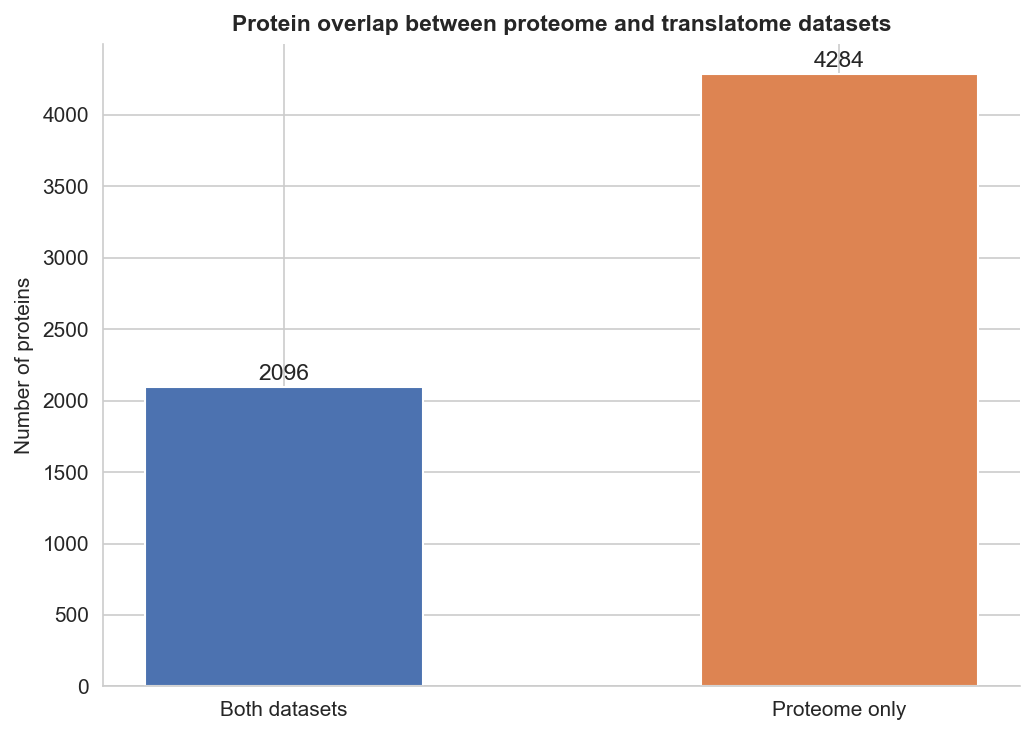

In [16]:
trans_acc  = set(trans_imp['Accession'])
prot_acc   = set(prot['UniProt Accession'])
overlap    = trans_acc & prot_acc
only_prot  = prot_acc - trans_acc
only_trans = trans_acc - prot_acc

print("--- Task 2: Protein overlap ---")
print(f"Proteins in BOTH datasets:    {len(overlap)}")
print(f"Proteins ONLY in proteome:    {len(only_prot)}")
print(f"Proteins ONLY in translatome: {len(only_trans)}")

# Bar plot
overlap_df = pd.DataFrame({
    'Category': ['Both datasets', 'Proteome only'],
    'Count':    [len(overlap),    len(only_prot)]
})

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(overlap_df['Category'], overlap_df['Count'],
              color=['#4C72B0', '#DD8452'], width=0.5)
for bar, count in zip(bars, overlap_df['Count']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            str(count), ha='center', fontsize=11)
ax.set_ylabel("Number of proteins", fontsize=10)
ax.set_title("Protein overlap between proteome and translatome datasets",
             fontsize=11, fontweight='bold')
ax.set_xlabel("")
sns.despine()
plt.tight_layout()
plt.savefig('W11_P2_T2_overlap.png', bbox_inches='tight')
plt.show()

## Discussion: Tasks 1 & 2 — Dataset size and protein overlap

### Task 1 — How many proteins were quantified?
The imputed translatome dataset contains 2,099 proteins, compared to 6,380
in the proteome dataset from Week 10 — roughly one third of the proteome size.
This difference is expected and biologically meaningful:

- The **proteome** measures ALL proteins present in the cell, including stable,
  long-lived proteins that have accumulated over days or weeks
- The **translatome** measures only NEWLY SYNTHESISED proteins actively being
  translated at the moment of measurement — proteins that are not being actively
  translated at a given timepoint will not appear

The lower number in the translatome also reflects a sensitivity difference: newly
synthesised proteins are present at lower absolute levels than the total accumulated
protein pool, meaning more proteins fall below the mass spectrometer detection limit.

**Viral proteins:** Only 5 of 17 annotated SARS-CoV-2 proteins were detected in
the translatome (Spike, ORF8, ORF9b, Nucleoprotein, ORF7a), compared to 9 in the
proteome. This suggests that some viral proteins detected in the total proteome
accumulated from earlier synthesis events and were no longer being actively
translated at the measured timepoints — or are present at levels too low for
translatome detection.

### Task 2 — Protein overlap between datasets
Of the 2,099 translatome proteins, all 2,099 are also found in the proteome
(2,096 shared proteins after matching on accession). Zero proteins are unique
to the translatome. This is an important internal consistency check: if a protein
is being actively synthesised (translatome), it must also be detectable in the
total protein pool (proteome). The 4,284 proteins found only in the proteome
represent stable, long-lived proteins present in the cell but not actively being
translated at the measured timepoints.

### Task 3: Viral protein expression profiles (raw)

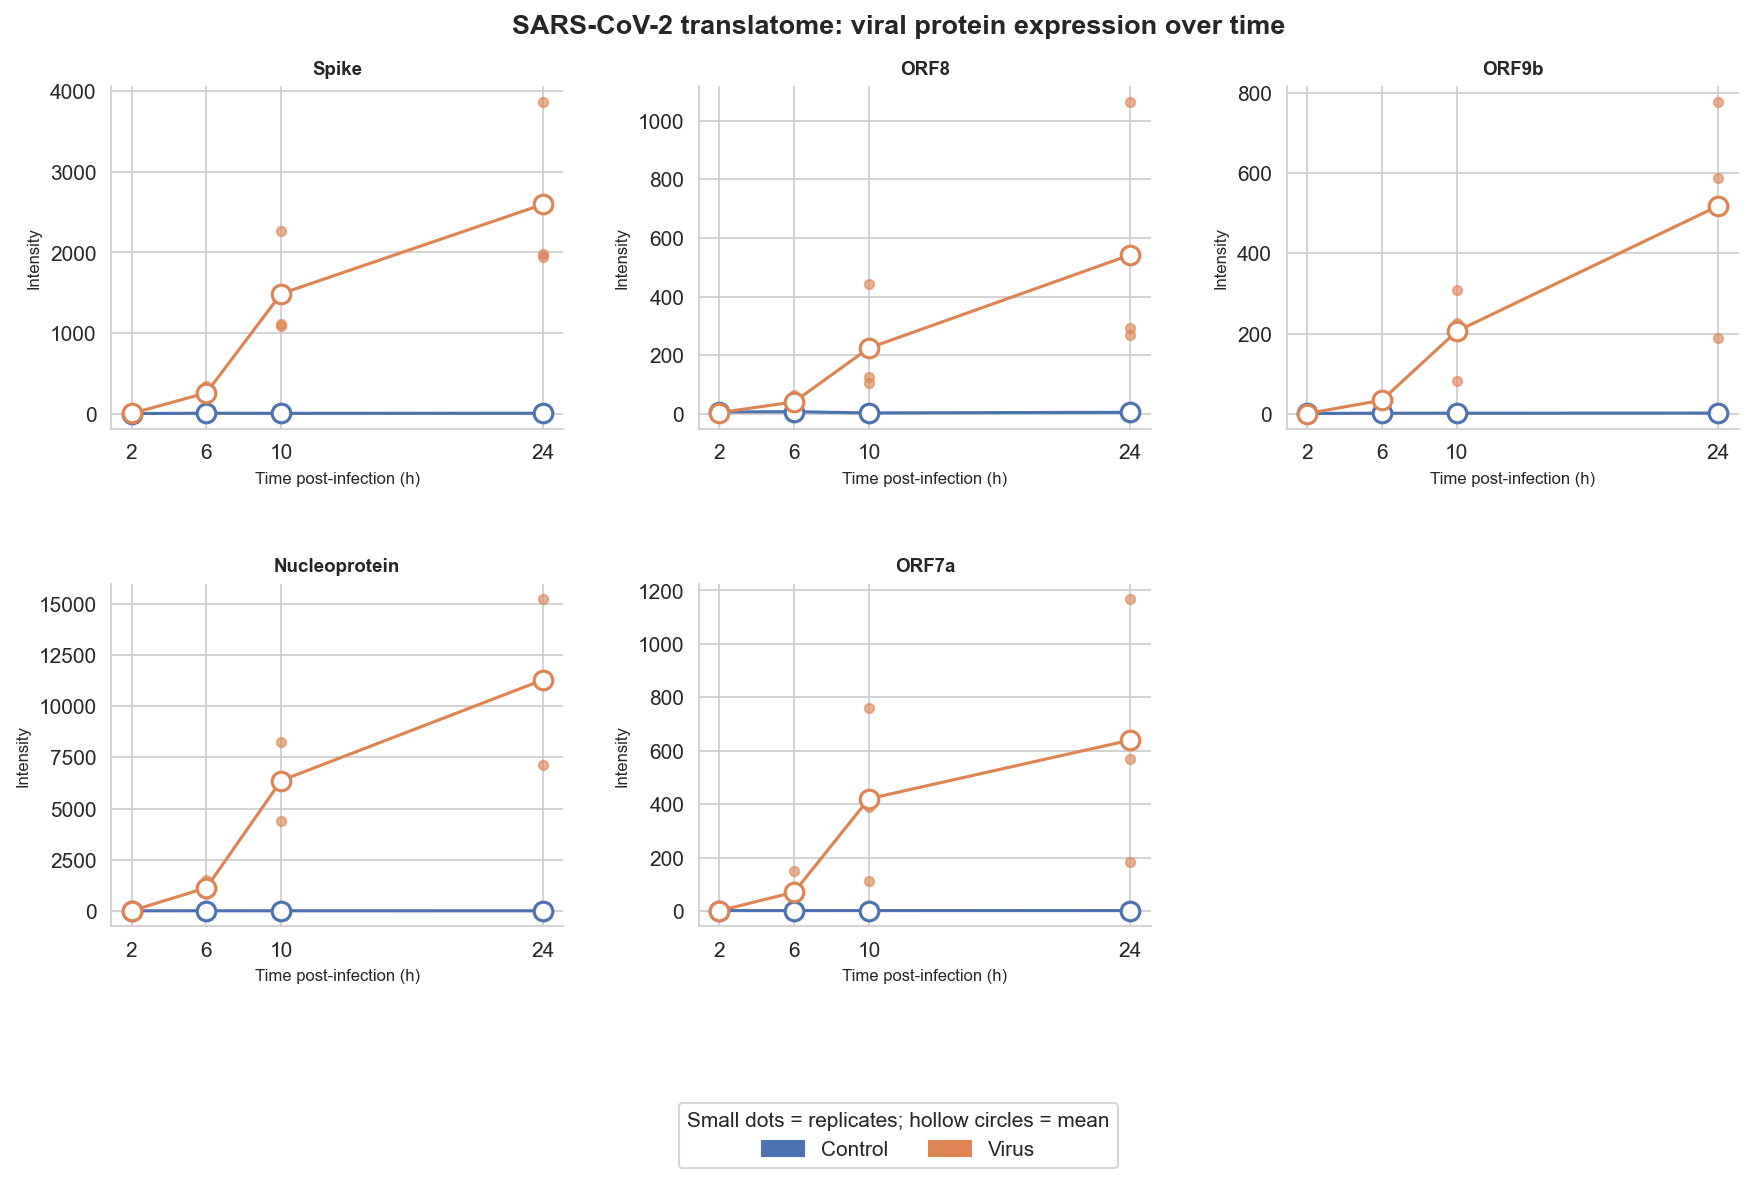

In [17]:
viral_df  = trans_imp[trans_imp['is_viral']].copy()
proteins  = viral_df['Viral_short_name'].dropna().tolist()
colours   = {'Control': '#4C72B0', 'Virus': '#DD8452'}

viral_long = viral_df[
    ['Accession', 'Viral_short_name'] + sample_cols
].melt(
    id_vars   = ['Accession', 'Viral_short_name'],
    var_name  = 'Sample',
    value_name= 'Intensity'
)
viral_long['Condition'] = viral_long['Sample'].apply(
    lambda x: 'Control' if 'Control' in x else 'Virus'
)
viral_long['Time_num'] = viral_long['Sample'].str.extract(r'(\d+)').astype(int)

viral_summary = viral_long.groupby(
    ['Accession', 'Viral_short_name', 'Condition', 'Time_num'],
    as_index=False
)['Intensity'].mean().rename(columns={'Intensity': 'mean_int'})

ncols = 3
nrows = int(np.ceil(len(proteins) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 8))
axes = axes.flatten()

for idx, protein in enumerate(proteins):
    ax = axes[idx]
    for condition, colour in colours.items():
        rep  = viral_long[(viral_long['Viral_short_name'] == protein) &
                          (viral_long['Condition'] == condition)]
        mean = viral_summary[(viral_summary['Viral_short_name'] == protein) &
                             (viral_summary['Condition'] == condition)
                             ].sort_values('Time_num')
        ax.scatter(rep['Time_num'], rep['Intensity'],
                   color=colour, alpha=0.6, s=20, zorder=2)
        ax.plot(mean['Time_num'], mean['mean_int'],
                color=colour, linewidth=1.5, zorder=3)
        ax.scatter(mean['Time_num'], mean['mean_int'],
                   color=colour, s=80, zorder=4,
                   edgecolors=colour, facecolors='white', linewidths=1.5)
    ax.set_title(protein, fontsize=9, fontweight='bold')
    ax.set_xlabel('Time post-infection (h)', fontsize=8)
    ax.set_ylabel('Intensity', fontsize=8)
    ax.set_xticks([2, 6, 10, 24])
    sns.despine(ax=ax)

for idx in range(len(proteins), len(axes)):
    axes[idx].set_visible(False)

handles = [mpatches.Patch(color=c, label=l) for l, c in colours.items()]
fig.suptitle('SARS-CoV-2 translatome: viral protein expression over time',
             fontsize=13, fontweight='bold')
fig.legend(handles=handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, 0.01),
           title='Small dots = replicates; hollow circles = mean')
fig.subplots_adjust(bottom=0.22, top=0.92, hspace=0.45, wspace=0.3)
plt.savefig('W11_P2_T3_viral_raw.png', bbox_inches='tight')
plt.show()

### Viral ratio plot

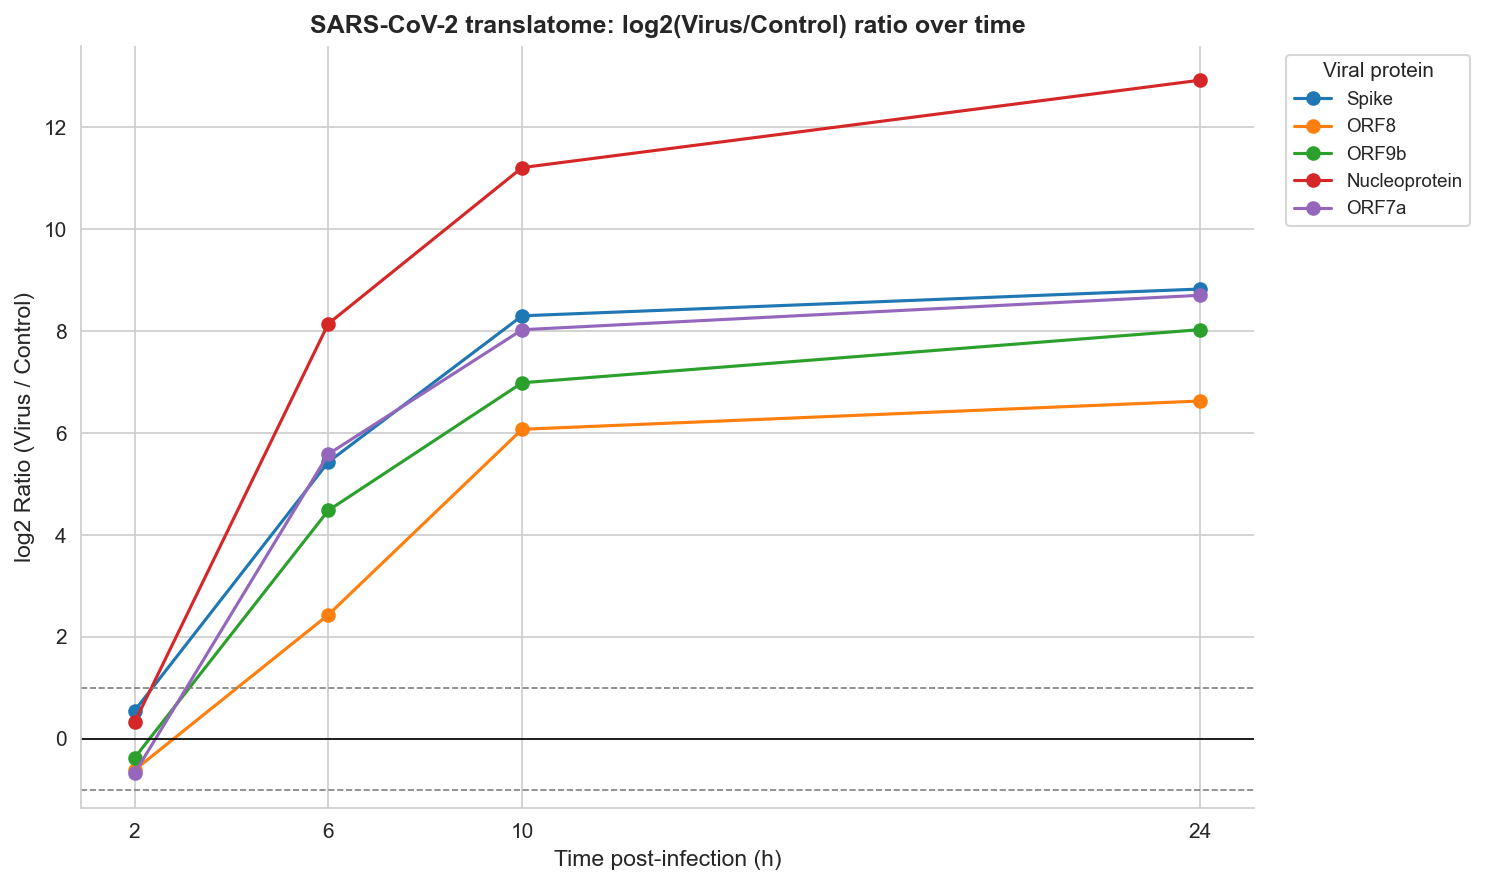

In [18]:
# Calculate ratio from means
viral_ratio_rows = []
for _, row in viral_df.iterrows():
    for tp in timepoints:
        ctrl_mean = row[[f"Control {tp}_{r}" for r in replicates]].mean()
        vir_mean  = row[[f"Virus {tp}_{r}"   for r in replicates]].mean()
        viral_ratio_rows.append({
            'Accession':       row['Accession'],
            'Viral_short_name': row['Viral_short_name'],
            'Timepoint':       tp,
            'Time_num':        int(tp.replace('h', '')),
            'log2_Ratio':      np.log2(vir_mean / ctrl_mean)
        })

viral_ratio = pd.DataFrame(viral_ratio_rows)

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette("tab10", n_colors=len(proteins))

for protein, colour in zip(proteins, palette):
    data = viral_ratio[viral_ratio['Viral_short_name'] == protein
                       ].sort_values('Time_num')
    ax.plot(data['Time_num'], data['log2_Ratio'],
            color=colour, linewidth=1.5,
            marker='o', markersize=6, label=protein)

ax.axhline(y=1,  linestyle='--', color='grey', linewidth=0.8)
ax.axhline(y=-1, linestyle='--', color='grey', linewidth=0.8)
ax.axhline(y=0,  linestyle='-',  color='black', linewidth=0.8)
ax.set_xticks([2, 6, 10, 24])
ax.set_xlabel('Time post-infection (h)', fontsize=11)
ax.set_ylabel('log2 Ratio (Virus / Control)', fontsize=11)
ax.set_title('SARS-CoV-2 translatome: log2(Virus/Control) ratio over time',
             fontsize=12, fontweight='bold')
ax.legend(title='Viral protein', bbox_to_anchor=(1.02, 1),
          loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('W11_P2_T3_viral_ratio.png', bbox_inches='tight')
plt.show()

## Discussion: Task 3 — Translatome viral protein expression profiles

### Method
The 5 detected SARS-CoV-2 proteins (Spike, ORF8, ORF9b, Nucleoprotein, ORF7a)
were plotted in two ways: (1) raw intensity values over time showing Control vs
Virus replicates, and (2) log2(Virus/Control) ratio values calculated from the
means of the three replicates at each timepoint.

### Result — Raw expression
All 5 viral proteins show the same clear pattern:
- **Control (blue):** flat line at near-zero across all timepoints, confirming
  no viral protein synthesis in uninfected cells
- **Virus (orange):** starts near zero at 2h, rises sharply from 6h onwards,
  continuing to increase through to 24h

Ranking of abundance at 24h: Nucleoprotein (~15,000) is by far the most
abundant, followed by Spike, ORF7a, ORF8 and ORF9b.

### Result — Ratio values
All 5 proteins show dramatically increasing log2 ratios over time, all well
above the significance threshold (log2 ≥ 1). Nucleoprotein reaches the highest
ratio (~13) by 24h; the others reach ~8–9. Notably, all proteins already
exceed log2 = 1 at 2h, suggesting active viral translation begins very early.

### Comparison to the proteome (Week 10)
Two important differences emerge compared to the proteome viral profiles:

1. **Earlier detection in translatome:** In the proteome, viral proteins showed
   minimal signal at 2h and 6h, only rising clearly at 10h. In the translatome,
   viral proteins are already being actively translated at 2h. This confirms
   that translational activity **precedes** protein accumulation — newly
   synthesised proteins need time to accumulate to detectable proteome levels.

2. **Higher fold-change ratios:** Translatome ratios reach ~13 for Nucleoprotein
   vs ~6 in the proteome. This is because control translatome values are
   essentially zero (no viral translation in uninfected cells), making the
   Virus/Control ratio much larger. Proteome control values have small background
   signals that compress the ratio.

3. **Fewer proteins detected:** Only 5 viral proteins appear in the translatome
   vs 9 in the proteome. Some viral proteins that accumulate stably in infected
   cells may no longer be actively translated at the specific timepoints measured.

### Task 4: Calculate log2 ratios and p-values

In [19]:
for tp in timepoints:
    ctrl = [f"Control {tp}_{r}" for r in replicates]
    vir  = [f"Virus {tp}_{r}"   for r in replicates]

    ctrl_mean = trans_imp[ctrl].mean(axis=1)
    vir_mean  = trans_imp[vir].mean(axis=1)
    trans_imp[f'ratio_{tp}'] = np.log2(vir_mean / ctrl_mean)

    pvals = trans_imp.apply(
        lambda row: stats.ttest_ind(
            row[vir].values.astype(float),
            row[ctrl].values.astype(float),
            equal_var=False
        ).pvalue,
        axis=1
    )
    trans_imp[f'pval_{tp}']      = pvals
    trans_imp[f'neglog10P_{tp}'] = -np.log10(pvals)

print("Fold change and p-value columns added.")
print([c for c in trans_imp.columns if 'ratio' in c or 'pval' in c])

Fold change and p-value columns added.
['ratio_2h', 'pval_2h', 'ratio_6h', 'pval_6h', 'ratio_10h', 'pval_10h', 'ratio_24h', 'pval_24h']


### Significance classification

In [20]:
def classify_sig(ratio, neglogP, fc_thresh=1, p_thresh=1.3):
    if ratio >= fc_thresh and neglogP >= p_thresh:
        return 'Up'
    elif ratio <= -fc_thresh and neglogP >= p_thresh:
        return 'Down'
    else:
        return 'NS'

for tp in timepoints:
    trans_imp[f'sig_{tp}'] = trans_imp.apply(
        lambda row: classify_sig(row[f'ratio_{tp}'],
                                 row[f'neglog10P_{tp}']),
        axis=1
    )

print("Significantly regulated HUMAN proteins per timepoint:")
for tp in timepoints:
    up   = ((trans_imp[f'sig_{tp}'] == 'Up')   & (~trans_imp['is_viral'])).sum()
    down = ((trans_imp[f'sig_{tp}'] == 'Down') & (~trans_imp['is_viral'])).sum()
    print(f"  {tp:4s} — Up: {up:3d}  Down: {down:3d}")

Significantly regulated HUMAN proteins per timepoint:
  2h   — Up:   8  Down:  16
  6h   — Up:   4  Down:  11
  10h  — Up:   1  Down:  35
  24h  — Up:  28  Down: 156


### Volcano plots

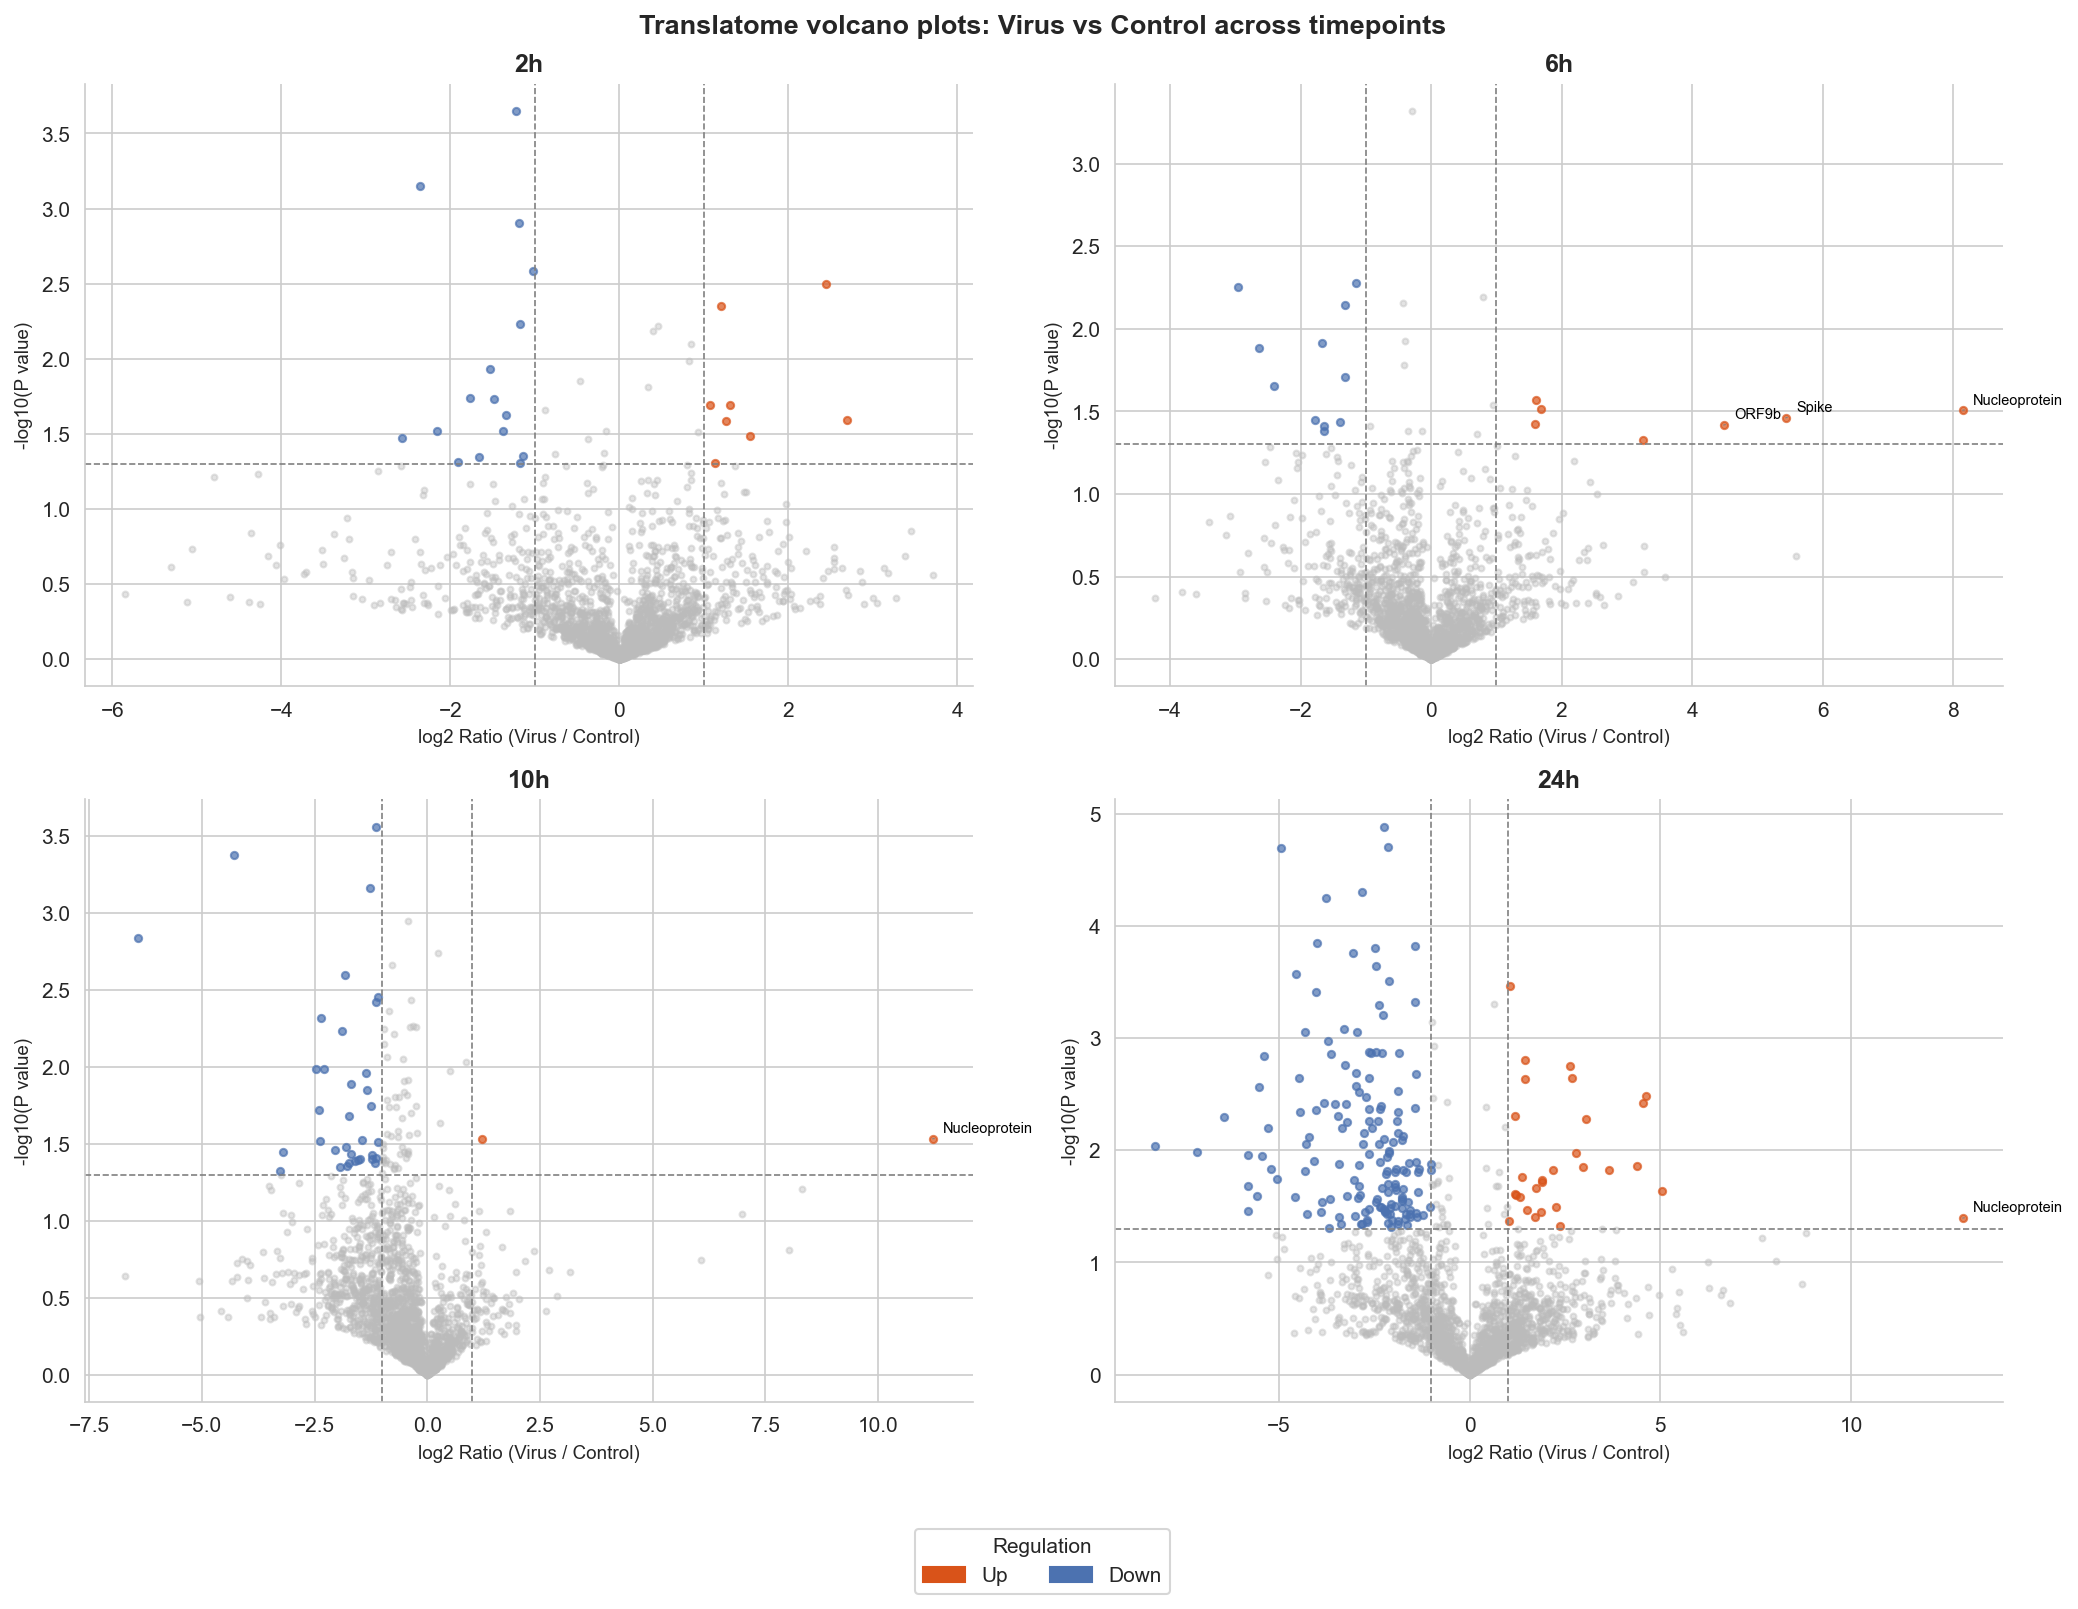

In [21]:
colours_sig = {'Up': '#D95319', 'Down': '#4C72B0', 'NS': '#BBBBBB'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, tp in zip(axes, timepoints):
    ratio_col   = f'ratio_{tp}'
    neglogP_col = f'neglog10P_{tp}'
    sig_col     = f'sig_{tp}'

    ns = trans_imp[trans_imp[sig_col] == 'NS']
    ax.scatter(ns[ratio_col], ns[neglogP_col],
               c=colours_sig['NS'], alpha=0.4, s=8, zorder=1)

    for sig in ['Down', 'Up']:
        subset = trans_imp[trans_imp[sig_col] == sig]
        ax.scatter(subset[ratio_col], subset[neglogP_col],
                   c=colours_sig[sig], alpha=0.7, s=12,
                   label=sig, zorder=2)

    # Label significant viral proteins using full readable names
    viral_sig = trans_imp[
        (trans_imp[sig_col] != 'NS') & (trans_imp['is_viral'])
    ]
    for _, row in viral_sig.iterrows():
        ax.annotate(
            row['Viral_short_name'],     # full name e.g. "Nucleoprotein"
            xy=(row[ratio_col], row[neglogP_col]),
            xytext=(5, 3), textcoords='offset points',
            fontsize=7, color='black',
            arrowprops=dict(arrowstyle='-', color='grey', lw=0.5)
        )

    ax.axvline(x=1,   linestyle='--', color='grey', linewidth=0.8)
    ax.axvline(x=-1,  linestyle='--', color='grey', linewidth=0.8)
    ax.axhline(y=1.3, linestyle='--', color='grey', linewidth=0.8)
    ax.set_title(tp, fontsize=12, fontweight='bold')
    ax.set_xlabel('log2 Ratio (Virus / Control)', fontsize=9)
    ax.set_ylabel('-log10(P value)', fontsize=9)
    sns.despine(ax=ax)

handles = [mpatches.Patch(color=c, label=l)
           for l, c in colours_sig.items() if l != 'NS']
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.08), fontsize=10,
           title='Regulation')
fig.suptitle('Translatome volcano plots: Virus vs Control across timepoints',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('W11_P2_T4_volcano.png', bbox_inches='tight')
plt.show()

## Discussion: Task 4 — Overall translatome change at each timepoint

### Method
Since the imputed translatome dataset does not include pre-calculated fold
changes or P values (unlike the Week 10 proteome data), these were calculated
manually:
- **log2 ratio** = log2(mean Virus / mean Control) for each timepoint
- **P values** calculated using a two-sided unpaired Welch's t-test
  (`scipy.stats.ttest_ind`, `equal_var=False`) comparing 3 virus vs 3 control
  replicates per protein
- **Significance thresholds:** log2 ratio ≥ 1 (or ≤ −1) AND −log10(P) ≥ 1.3
  (P < 0.05)

Welch's t-test was chosen over Student's t-test because it does not assume
equal variance between conditions — more appropriate for biological data where
variance commonly differs between groups, especially after imputation.

### Result — Significantly regulated human proteins
| Timepoint | Up | Down |
|-----------|-----|------|
| 2h        |  8  |  16  |
| 6h        |  4  |  11  |
| 10h       |  1  |  35  |
| 24h       | 28  | 156  |

### Volcano plot interpretation
- **2h:** Already shows some significantly regulated proteins in both directions.
  This is notably earlier than the proteome response (which showed nothing at 2h),
  confirming that translational changes precede protein accumulation changes.
- **6h:** Fewer significantly regulated proteins than 2h. Nucleoprotein, Spike
  and ORF9b appear as the first significantly elevated viral proteins.
- **10h:** Strong down-regulation signal — 35 human proteins significantly
  down-regulated vs only 1 up-regulated. Nucleoprotein appears far right with
  very high fold change (~log2 12), the largest signal in any timepoint.
- **24h:** The most dramatic response overall. 156 down-regulated and 28
  up-regulated human proteins. The left side shows a large dense cluster of
  significantly down-regulated proteins.

### Comparison to the proteome volcano plots (Week 10)
- **More down-regulation in translatome:** 156 down-regulated at 24h vs 18 in
  the proteome, suggesting SARS-CoV-2 strongly suppresses NEW protein synthesis
  of many host proteins well before existing stable proteins are depleted
- **Earlier response:** Significant changes appear at 2h in the translatome vs
  not until 6h–10h in the proteome
- **Larger fold changes:** Translatome ratios reach up to log2 ~12 vs log2 ~6
  in the proteome, due to the near-zero control translatome baseline
- **Lower statistical significance:** Many translatome points have lower −log10 P
  values compared to the proteome, likely reflecting higher replicate variability
  in translatome measurements

### Task 5: Filter significant human proteins at 24h

In [22]:
sig_24h_up   = trans_imp[
    (~trans_imp['is_viral']) & (trans_imp['sig_24h'] == 'Up')
].copy()
sig_24h_down = trans_imp[
    (~trans_imp['is_viral']) & (trans_imp['sig_24h'] == 'Down')
].copy()

# Clean gene names
sig_24h_up['Gene Symbol']   = sig_24h_up['Gene Symbol'].str.split(';').str[0]
sig_24h_down['Gene Symbol'] = sig_24h_down['Gene Symbol'].str.split(';').str[0]

print(f"Significantly UP   at 24h (human): {len(sig_24h_up)}")
print(f"Significantly DOWN at 24h (human): {len(sig_24h_down)}")

print("\nTop 10 most UP-regulated at 24h:")
print(sig_24h_up[['Gene Symbol', 'ratio_24h', 'pval_24h']]
      .sort_values('ratio_24h', ascending=False)
      .head(10).to_string(index=False))

print("\nTop 10 most DOWN-regulated at 24h:")
print(sig_24h_down[['Gene Symbol', 'ratio_24h', 'pval_24h']]
      .sort_values('ratio_24h')
      .head(10).to_string(index=False))

Significantly UP   at 24h (human): 28
Significantly DOWN at 24h (human): 156

Top 10 most UP-regulated at 24h:
Gene Symbol  ratio_24h  pval_24h
      YWHAZ   5.035376  0.023231
      CEBPZ   4.627693  0.003286
       GDI1   4.545825  0.003770
     AKAP12   4.375024  0.013705
      PRDX6   3.661745  0.015147
     ATP5A1   3.061815  0.005244
       RER1   2.976008  0.013966
      RPL36   2.799995  0.010674
     CCDC47   2.671787  0.002250
       YARS   2.641738  0.001782

Top 10 most DOWN-regulated at 24h:
Gene Symbol  ratio_24h  pval_24h
      APOA1  -8.237023  0.009158
     CTNNA1  -7.143767  0.010391
      UBE2C  -6.439938  0.005071
     ABHD10  -5.814847  0.011082
      VPS35  -5.807248  0.020671
      HADHA  -5.797323  0.034876
        PPL  -5.562601  0.025705
    DYNLRB1  -5.522104  0.002722
       EIF1  -5.429808  0.011315
       EHD1  -5.377947  0.001437


### Helper functions for line plots

In [23]:
def reshape_for_plot(df, sample_cols):
    long = df[['Accession', 'Gene Symbol'] + sample_cols].melt(
        id_vars   = ['Accession', 'Gene Symbol'],
        var_name  = 'Sample',
        value_name= 'Intensity'
    )
    long['Intensity']       = long['Intensity'].where(long['Intensity'] > 0, np.nan)
    long['log10_intensity'] = np.log10(long['Intensity'])
    long['Condition']       = long['Sample'].apply(
        lambda x: 'Control' if 'Control' in x else 'Virus'
    )
    long['Time_num'] = long['Sample'].str.extract(r'(\d+)').astype(float)
    summary = long.groupby(
        ['Gene Symbol', 'Condition', 'Time_num'], as_index=False
    )['log10_intensity'].mean().rename(
        columns={'log10_intensity': 'mean_log10'}
    )
    return long, summary

def make_lineplot(df, sample_cols, plot_title, ncols=4, figsize=(14, 10)):
    long, summary = reshape_for_plot(df, sample_cols)
    genes  = df['Gene Symbol'].unique()
    nrows  = int(np.ceil(len(genes) / ncols))
    colours = {'Control': '#4C72B0', 'Virus': '#DD8452'}

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for idx, gene in enumerate(genes):
        ax = axes[idx]
        for condition, colour in colours.items():
            rep  = long[(long['Gene Symbol'] == gene) &
                        (long['Condition'] == condition)]
            mean = summary[(summary['Gene Symbol'] == gene) &
                           (summary['Condition'] == condition)
                           ].sort_values('Time_num')
            ax.scatter(rep['Time_num'], rep['log10_intensity'],
                       color=colour, alpha=0.4, s=15, zorder=2)
            ax.plot(mean['Time_num'], mean['mean_log10'],
                    color=colour, linewidth=1.2, zorder=3)
            ax.scatter(mean['Time_num'], mean['mean_log10'],
                       color=colour, s=50, zorder=4,
                       edgecolors=colour, facecolors='white',
                       linewidths=1.5)
        ax.set_title(gene, fontsize=7, fontweight='bold')
        ax.set_xlabel('Time (h)', fontsize=7)
        ax.set_ylabel('log10(Intensity)', fontsize=7)
        ax.set_xticks([2, 6, 10, 24])
        ax.tick_params(labelsize=6)
        sns.despine(ax=ax)

    for idx in range(len(genes), len(axes)):
        axes[idx].set_visible(False)

    handles = [mpatches.Patch(color=c, label=l) for l, c in colours.items()]
    fig.legend(handles=handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, 0.01),
           title='Small dots = replicates; hollow circles = mean')
    fig.suptitle(plot_title, fontsize=11, fontweight='bold')
    fig.subplots_adjust(bottom=0.08, top=0.95, hspace=0.65, wspace=0.35)
    return fig

### Plot up-regulated proteins

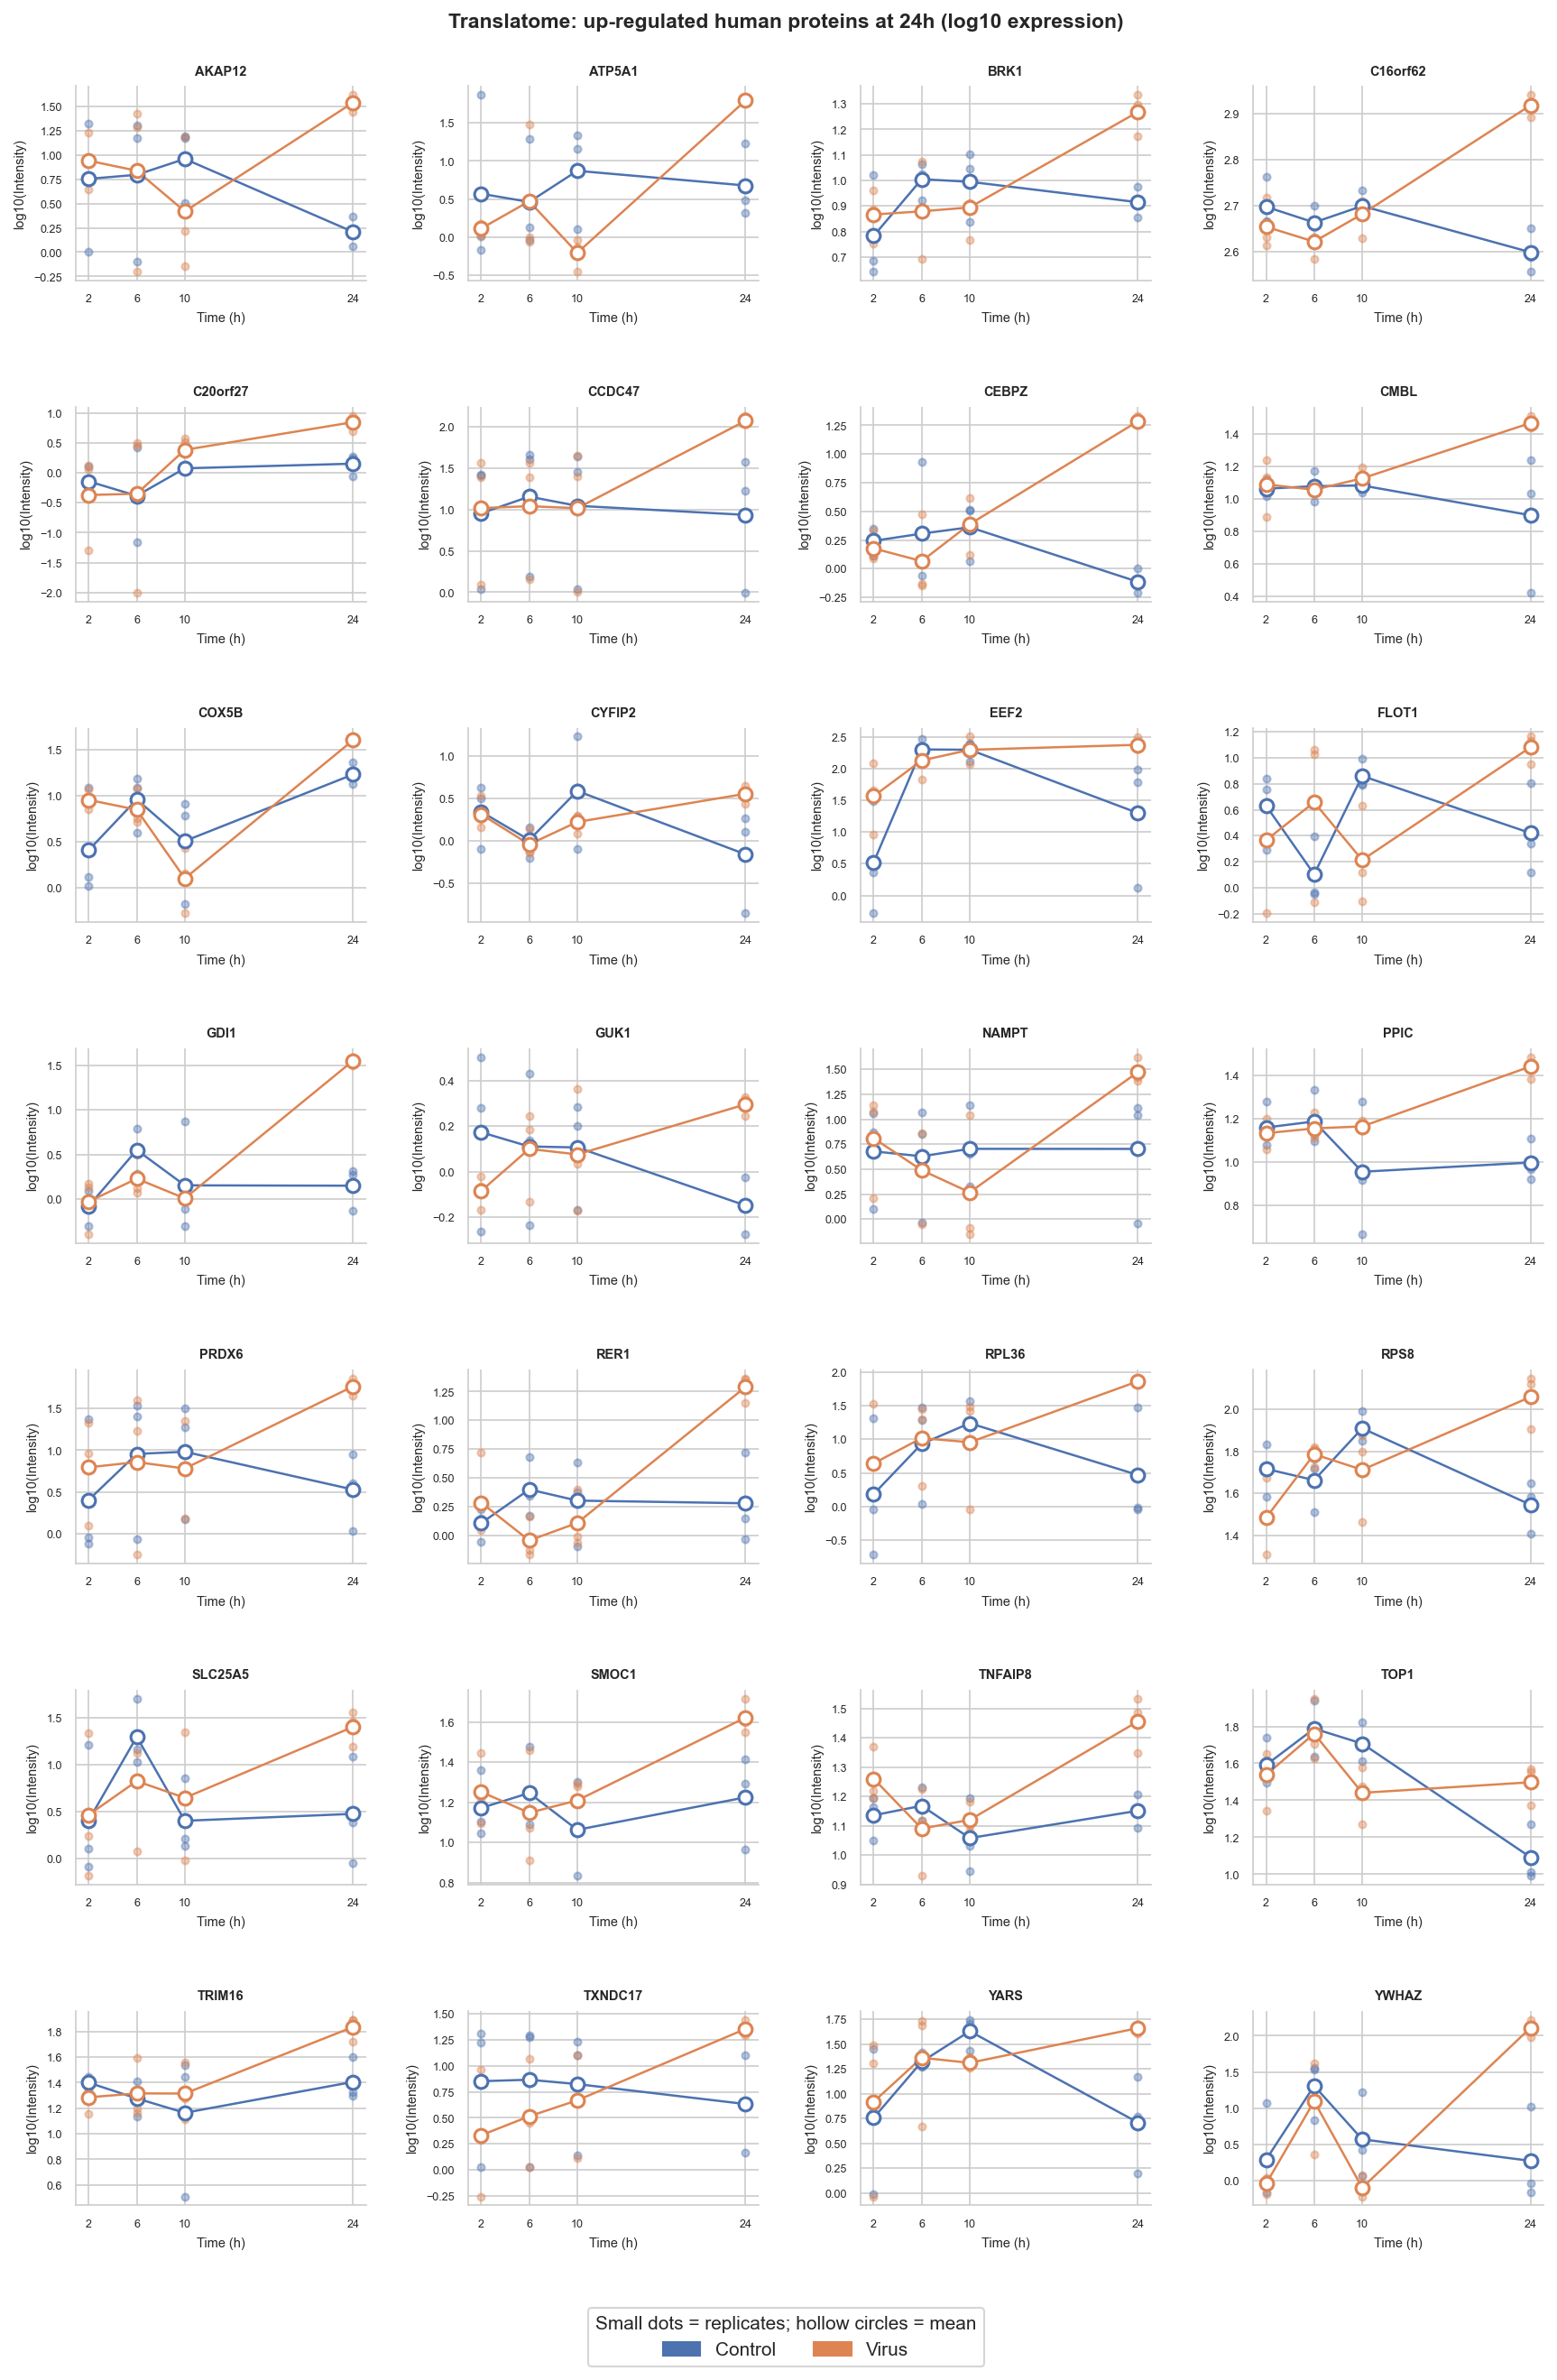

In [24]:
sig_24h_up = sig_24h_up.sort_values('Gene Symbol').reset_index(drop=True)

fig_up = make_lineplot(
    sig_24h_up, sample_cols,
    "Translatome: up-regulated human proteins at 24h (log10 expression)",
    ncols=4, figsize=(14, 18)   # taller figure for 7 rows
)
plt.savefig('W11_P2_T5_human_up.png', bbox_inches='tight')
plt.show()

### Plot top 40 down-regulated proteins

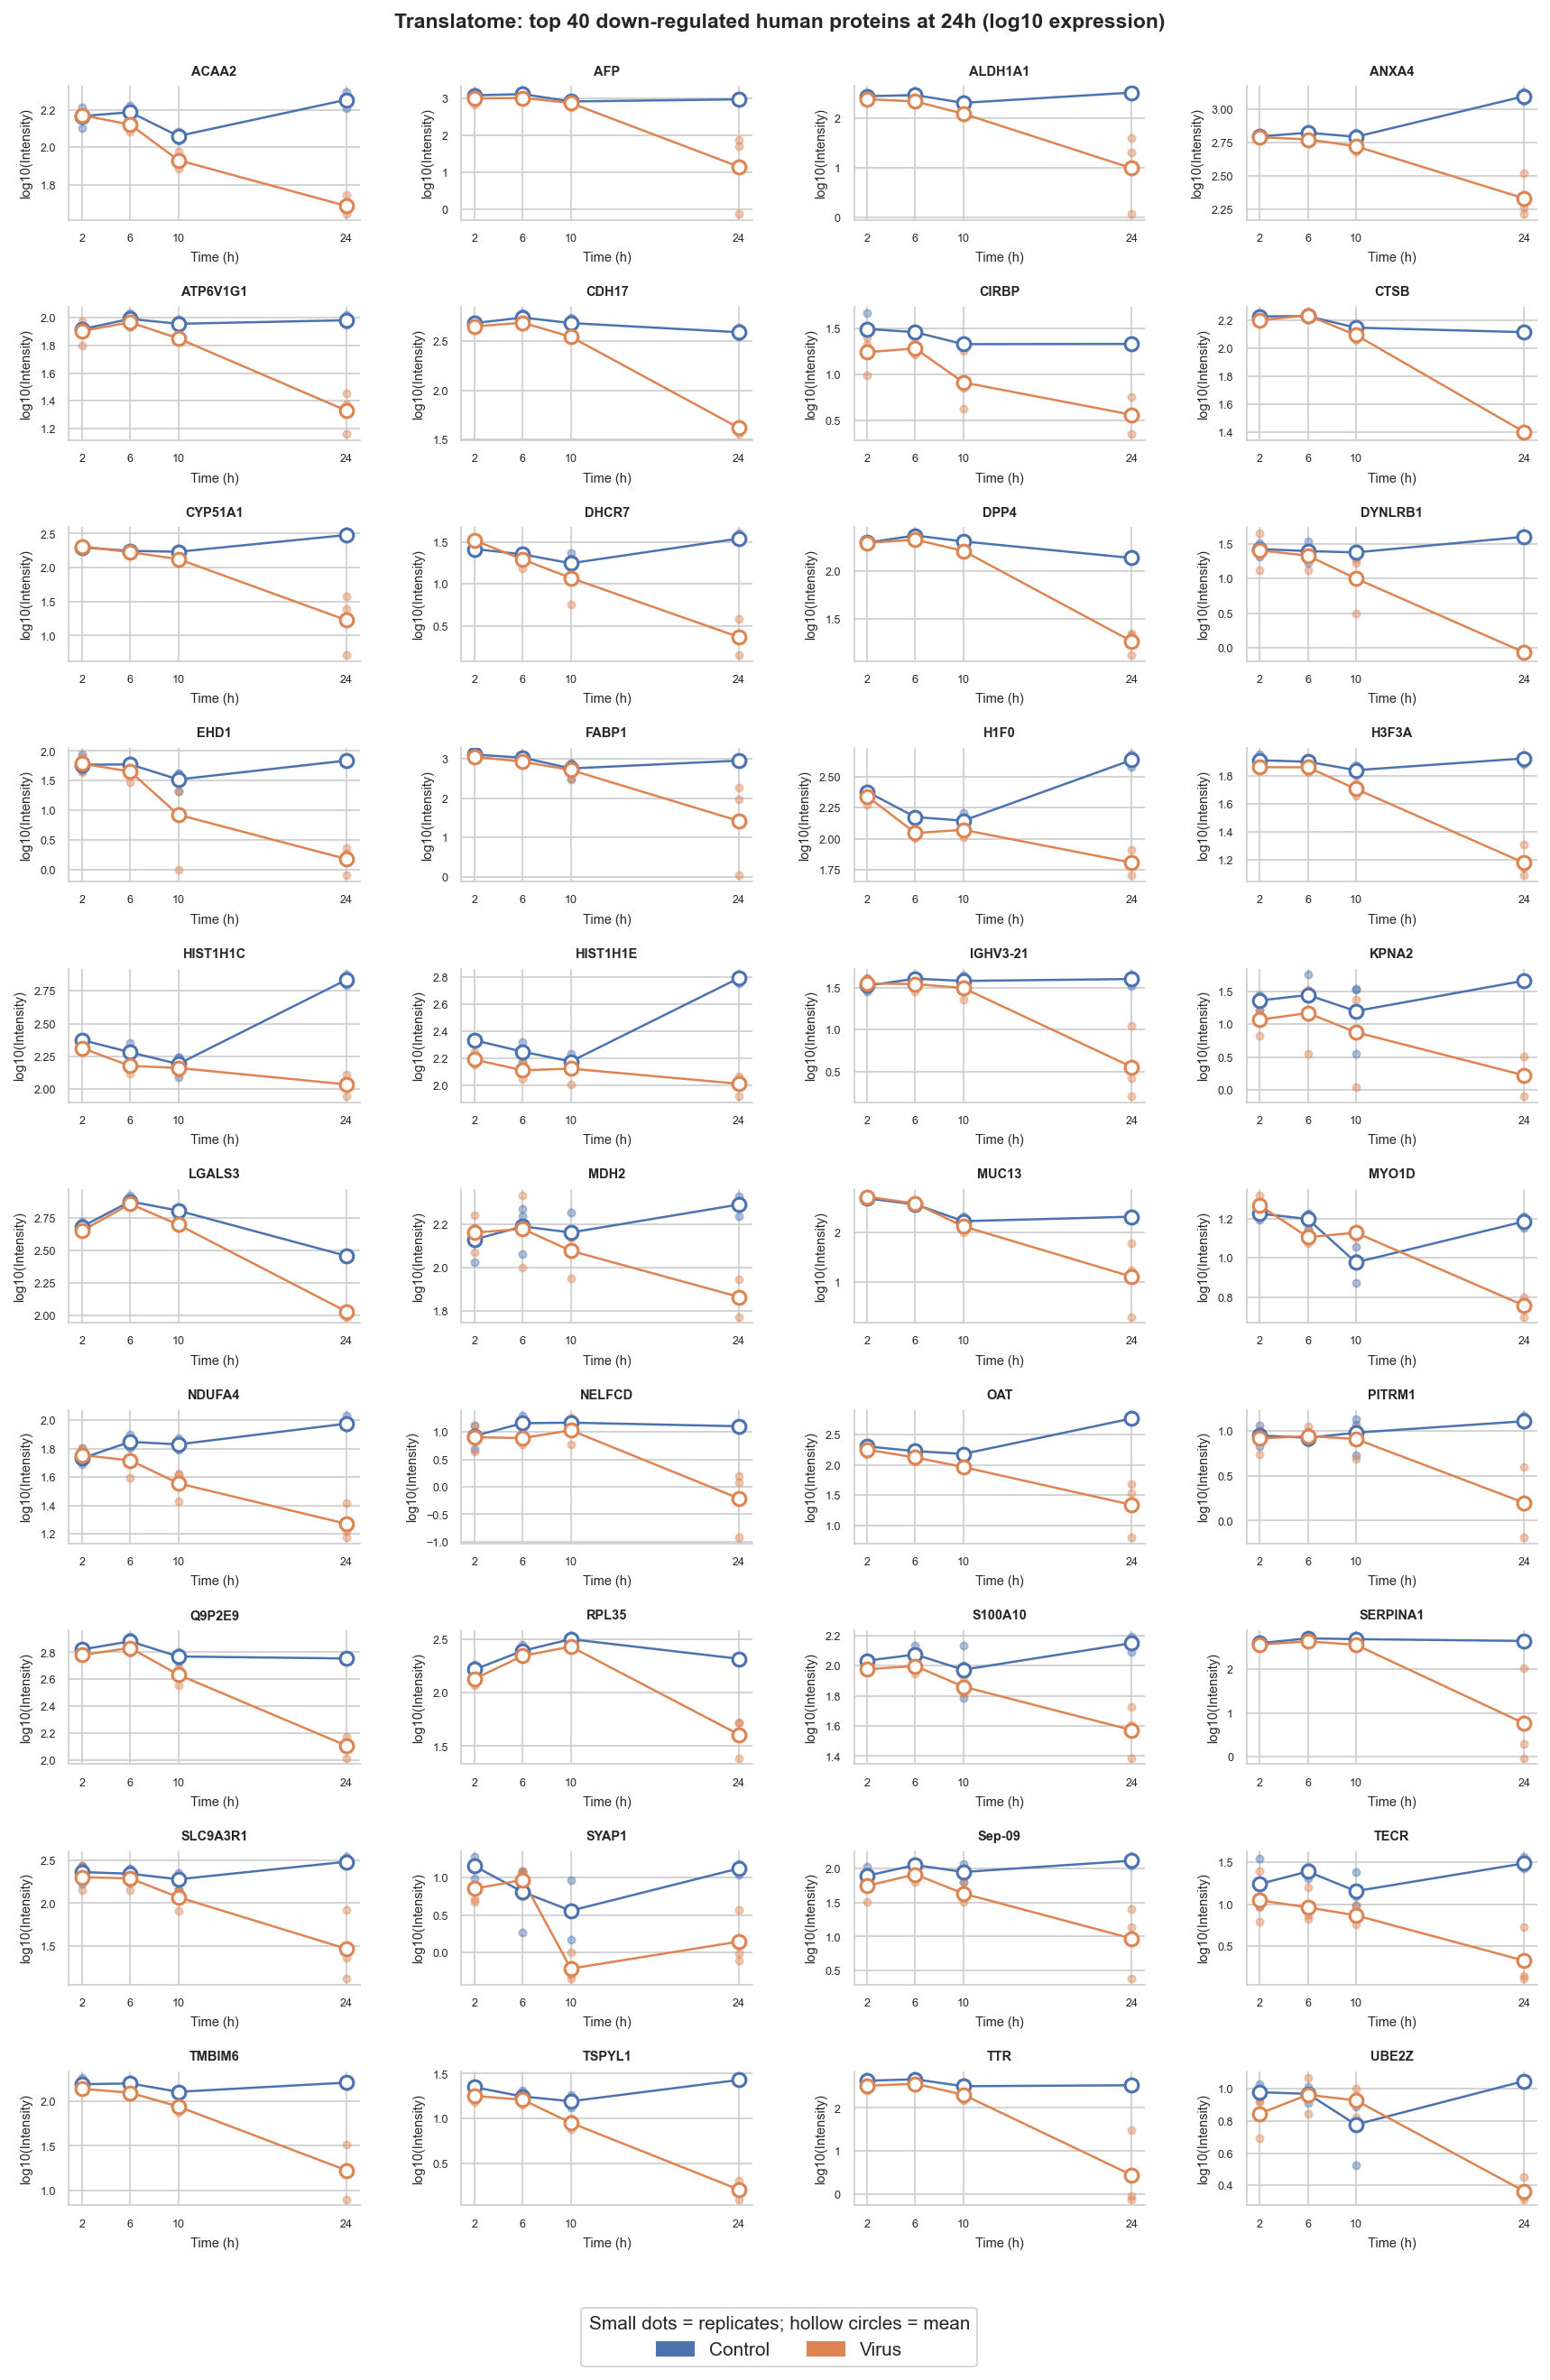

In [25]:
# 156 down-regulated is too many — take top 40 most significant
top40_down = sig_24h_down.sort_values('pval_24h').head(40)
top40_down = top40_down.copy()
top40_down['Gene Symbol'] = top40_down.apply(
    lambda row: row['Accession'] if pd.isna(row['Gene Symbol']) else row['Gene Symbol'],
    axis=1
)

top40_down = top40_down.sort_values('Gene Symbol').reset_index(drop=True)

fig_down = make_lineplot(
    top40_down, sample_cols,
    "Translatome: top 40 down-regulated human proteins at 24h (log10 expression)",
    ncols=4, figsize=(14, 18)
)
plt.savefig('W11_P2_T5_human_down.png', bbox_inches='tight')
plt.show()

## Discussion: Task 5 — Significantly regulated human proteins at 24h

### Method
Human proteins significantly regulated at 24h were filtered using thresholds of
log2 ratio ≥ 1 (or ≤ −1) and P value ≤ 0.05. Due to the large number of
down-regulated proteins (156), only the top 40 most statistically significant
were plotted, selected by lowest P value. Proteins were sorted alphabetically
by gene symbol before plotting to match the standard panel ordering convention.

One protein with a missing gene symbol in the database was retained in the
analysis by substituting its UniProt accession as the label rather than dropping
it, ensuring no data loss.

Gene names containing semicolons (indicating multiple database entries for the
same protein) were simplified to the first gene name only for clean plot labelling.

### Result — Up-regulated proteins (28 proteins)
Top 10 most up-regulated by fold change:

| Gene Symbol | log2 Ratio (24h) | Biological function |
|-------------|-----------------|---------------------|
| YWHAZ | 5.04 | 14-3-3 protein — signal transduction hub |
| CEBPZ | 4.63 | Transcription factor |
| GDI1  | 4.55 | GDP dissociation inhibitor — vesicle trafficking |
| AKAP12 | 4.38 | Scaffolding protein — signal transduction |
| PRDX6 | 3.66 | Antioxidant enzyme — oxidative stress response |
| ATP5A1 | 3.06 | ATP synthase subunit — energy production |
| RER1  | 2.98 | ER membrane protein — protein retention in ER |
| RPL36 | 2.80 | Ribosomal protein — translation machinery |
| CCDC47 | 2.67 | ER membrane protein |
| YARS  | 2.64 | Aminoacyl-tRNA synthetase — translation |

From the lineplots, most up-regulated proteins show the orange (virus) line rising
clearly above the blue (control) line by 24h, typically beginning the increase
at 10–24h. Ribosomal proteins (RPL36, RPS8, EEF2) and translation factors (YARS)
are prominently up-regulated, suggesting the virus hijacks host translation
machinery for viral protein production. ER-associated proteins (RER1, CCDC47)
are consistent with coronaviruses replicating within the ER membrane network.

### Result — Down-regulated proteins (top 40 of 156 shown)
Top 10 most down-regulated by fold change:

| Gene Symbol | log2 Ratio (24h) | Biological function |
|-------------|-----------------|---------------------|
| APOA1  | −8.24 | Apolipoprotein — lipid metabolism |
| CTNNA1 | −7.14 | Alpha-catenin — cell adhesion |
| UBE2C  | −6.44 | Ubiquitin conjugating enzyme — protein degradation |
| ABHD10 | −5.81 | Metabolic enzyme |
| VPS35  | −5.81 | Retromer complex — vesicle trafficking |
| HADHA  | −5.80 | Fatty acid oxidation enzyme |
| PPL    | −5.56 | Periplakin — cytoskeletal protein |
| DYNLRB1 | −5.52 | Dynein motor complex — intracellular transport |
| EIF1   | −5.43 | Translation initiation factor |
| EHD1   | −5.38 | Endosomal recycling |

From the lineplots, down-regulated proteins show the orange (virus) line declining
clearly below the blue (control) line, with the decrease often beginning at
earlier timepoints and becoming most pronounced by 24h.

### Biological interpretation
The pattern of down-regulation reflects broad suppression of normal host cell
functions during peak viral replication:
- **Lipid metabolism** (APOA1, HADHA, DHCR7, CYP51A1): virus suppresses host
  lipid synthesis, likely redirecting lipids for viral membrane formation
- **Cell adhesion** (CTNNA1, CDH17): breakdown of cell-cell contacts may
  facilitate viral spread
- **Vesicle trafficking** (VPS35, EHD1, DYNLRB1): suppression of normal
  endosomal pathways
- **Translation initiation** (EIF1): selective suppression of host translation
  while promoting viral translation
- **Histones** (H1F0, H3F3A, HIST1H1C, HIST1H1E): changes in chromatin
  structure reflecting altered host gene expression

**Note on 'Sep-09':** This is SEPT9 (Septin-9), a protein involved in
cytokinesis. The name was automatically converted to a date format by Excel
— a known issue where Excel misinterprets certain gene names as dates
(e.g. SEPT9 → Sep-09, MARCH1 → 1-Mar). The gene symbol is stored incorrectly
in the source file and cannot be fixed without editing the original data.

### Comparison to the proteome (Week 10)
Several proteins appear in both datasets as down-regulated — notably AFP, TTR
and TMBIM6. This overlap confirms these are genuine biological effects of
infection rather than technical artefacts. The translatome shows many more
down-regulated proteins (156) than the proteome (18), suggesting widespread
suppression of new protein synthesis that has not yet manifested as reduced
protein levels in the total proteome.

### Task 6: Prepare fold changes for correlation

In [26]:
# Proteome — use pre-computed ratio columns from Week 10
prot_fc = prot[
    ['UniProt Accession', 'Gene Symbol', 'is_viral',
     'Ratio 2h', 'Ratio 6h', 'Ratio 10h', 'Ratio 24h']
].rename(columns={
    'UniProt Accession': 'Accession',
    'Gene Symbol':       'Gene_Symbol',
    'Ratio 2h':          'prot_ratio_2h',
    'Ratio 6h':          'prot_ratio_6h',
    'Ratio 10h':         'prot_ratio_10h',
    'Ratio 24h':         'prot_ratio_24h'
})

# Translatome — use calculated ratio columns
trans_fc = trans_imp[
    ['Accession', 'Gene Symbol', 'is_viral', 'Viral_short_name',
     'ratio_2h', 'ratio_6h', 'ratio_10h', 'ratio_24h']
].rename(columns={
    'Gene Symbol':  'Gene_Symbol',
    'ratio_2h':     'trans_ratio_2h',
    'ratio_6h':     'trans_ratio_6h',
    'ratio_10h':    'trans_ratio_10h',
    'ratio_24h':    'trans_ratio_24h'
})

# Inner join on shared accessions
combined = prot_fc.merge(
    trans_fc[['Accession', 'Viral_short_name',
              'trans_ratio_2h', 'trans_ratio_6h',
              'trans_ratio_10h', 'trans_ratio_24h']],
    on='Accession', how='inner'
)

print(f"Proteins in both datasets for correlation: {len(combined)}")

# Pearson correlation at each timepoint
print("\nCorrelation between proteome and translatome fold changes:")
for tp in timepoints:
    pc = f'prot_ratio_{tp}'
    tc = f'trans_ratio_{tp}'
    clean = combined[[pc, tc]].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    r, p = stats.pearsonr(clean[pc], clean[tc])
    print(f"  {tp:4s} — Pearson r = {r:.3f}  (n = {len(clean)} proteins)")

Proteins in both datasets for correlation: 2099

Correlation between proteome and translatome fold changes:
  2h   — Pearson r = 0.281  (n = 2099 proteins)
  6h   — Pearson r = 0.285  (n = 2099 proteins)
  10h  — Pearson r = 0.459  (n = 2099 proteins)
  24h  — Pearson r = 0.397  (n = 2099 proteins)


### Scatter plots for all 4 timepoints

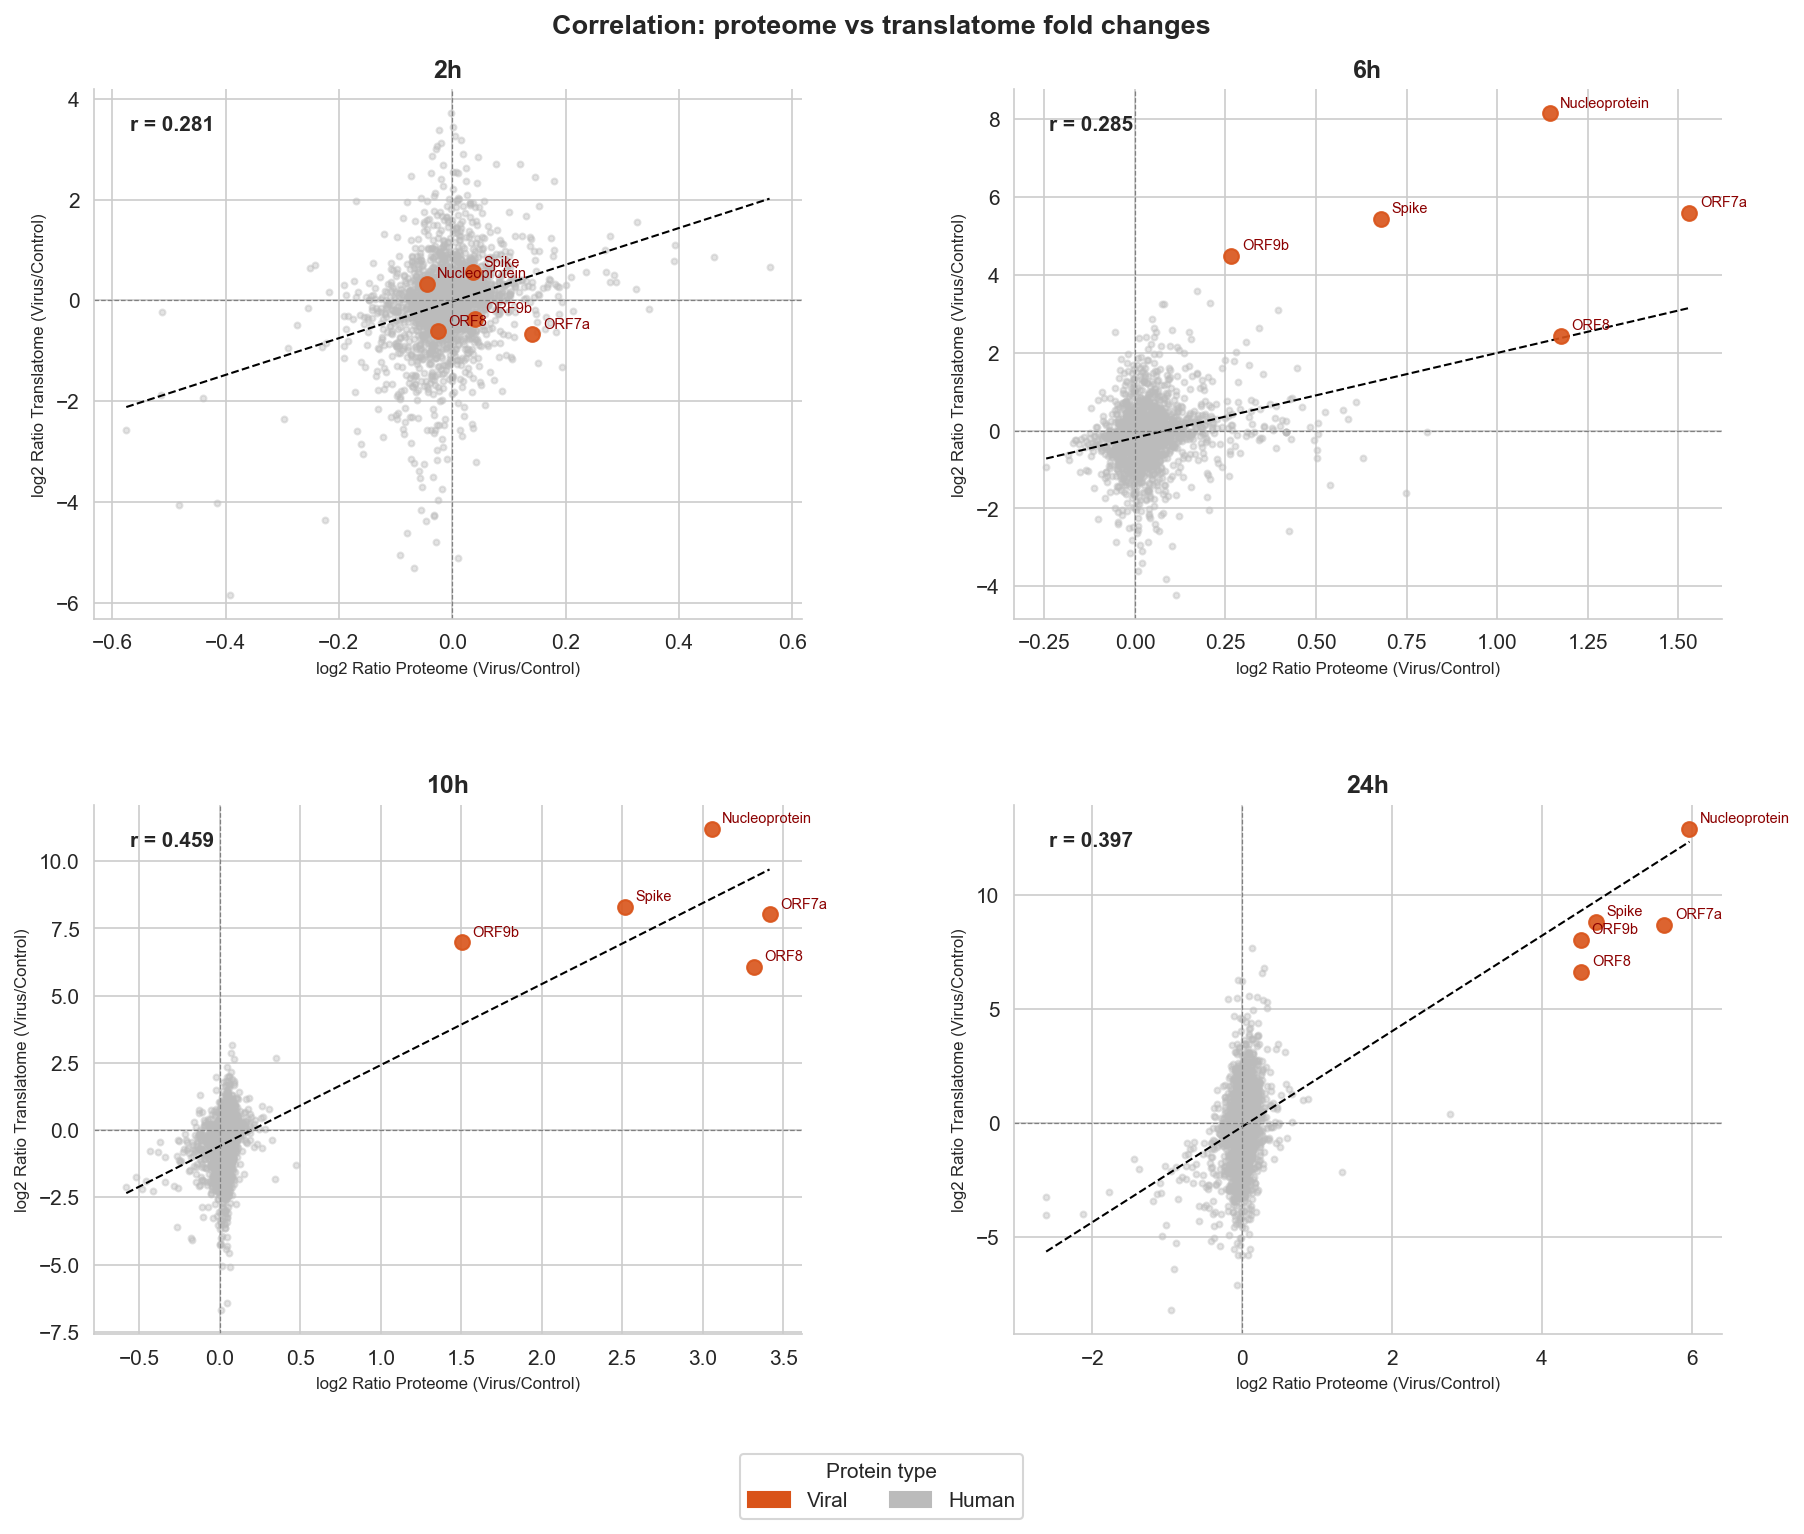

In [27]:
colours_point = {'Viral': '#D95319', 'Human': '#BBBBBB'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, tp in zip(axes, timepoints):
    pc    = f'prot_ratio_{tp}'
    tc    = f'trans_ratio_{tp}'
    clean = combined[[pc, tc, 'is_viral', 'Viral_short_name',
                      'Gene_Symbol']].replace(
        [np.inf, -np.inf], np.nan
    ).dropna(subset=[pc, tc])

    r, _ = stats.pearsonr(clean[pc], clean[tc])

    human = clean[~clean['is_viral']]
    viral = clean[clean['is_viral']]

    ax.scatter(human[pc], human[tc],
               color='#BBBBBB', alpha=0.4, s=8, zorder=1,
               label='Human')
    ax.scatter(viral[pc], viral[tc],
               color='#D95319', alpha=0.9, s=50, zorder=3,
               label='SARS-CoV-2')

    # Label viral proteins with full readable names
    for _, row in viral.iterrows():
        ax.annotate(
            row['Viral_short_name'],   # e.g. "Nucleoprotein"
            xy=(row[pc], row[tc]),
            xytext=(5, 3), textcoords='offset points',
            fontsize=7, color='darkred'
        )

    # Regression line
    m, b = np.polyfit(clean[pc], clean[tc], 1)
    x_range = np.linspace(clean[pc].min(), clean[pc].max(), 100)
    ax.plot(x_range, m * x_range + b,
            color='black', linewidth=1.0, linestyle='--')

    ax.axhline(y=0, color='grey', linewidth=0.6, linestyle='--')
    ax.axvline(x=0, color='grey', linewidth=0.6, linestyle='--')
    ax.text(0.05, 0.95, f'r = {r:.3f}',
            transform=ax.transAxes,
            fontsize=10, fontweight='bold', va='top')
    ax.set_title(tp, fontsize=12, fontweight='bold')
    ax.set_xlabel('log2 Ratio Proteome (Virus/Control)', fontsize=8)
    ax.set_ylabel('log2 Ratio Translatome (Virus/Control)', fontsize=8)
    sns.despine(ax=ax)

handles = [mpatches.Patch(color=c, label=l)
           for l, c in colours_point.items()]
fig.legend(handles=handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.03), fontsize=10,
           title='Protein type')
fig.suptitle('Correlation: proteome vs translatome fold changes',
             fontsize=13, fontweight='bold')
plt.subplots_adjust(bottom=0.1, top=0.93, hspace=0.35, wspace=0.3)
plt.savefig('W11_P2_T6_correlation.png', bbox_inches='tight')
plt.show()

## Discussion: Task 6 — Correlation between proteome and translatome fold changes

### Method
Proteome fold changes (pre-calculated log2 ratios from Week 10) and translatome
fold changes (calculated in Task 4) were joined by UniProt accession using an
inner join, retaining only proteins present in both datasets (n = 2,096).
Pearson correlation coefficients were calculated for all shared proteins at each
timepoint. The analysis was then restricted to the 5 SARS-CoV-2 proteins
detected in both datasets.

### Result — Overall correlation (all proteins)
| Timepoint | Pearson r | n proteins |
|-----------|-----------|-----------|
| 2h        | 0.281     | 2,096     |
| 6h        | 0.285     | 2,096     |
| 10h       | 0.459     | 2,096     |
| 24h       | 0.397     | 2,096     |

### Result — SARS-CoV-2 proteins only
| Timepoint | Pearson r | n proteins |
|-----------|-----------|-----------|
| 2h        | −0.409    | 5         |
| 6h        | 0.149     | 5         |
| 10h       | 0.180     | 5         |
| 24h       | 0.820     | 5         |

### Interpretation — Overall correlation
All timepoints show a **moderate positive correlation** (r = 0.28–0.46) between
proteome and translatome fold changes. This confirms that translational regulation
is a major driver of protein level changes during SARS-CoV-2 infection — proteins
that are more actively translated tend to accumulate at higher levels.

The correlation **increases from 2h to 10h** before slightly decreasing at 24h.
This reflects the biological time delay between translation and protein accumulation:
- At **2h**: translation changes are just beginning but have not yet manifested
  as detectable changes in the total proteome → low correlation
- At **10h**: translational changes from earlier timepoints have had time to
  accumulate as protein level changes → higher correlation
- At **24h**: complex interplay of protein synthesis, degradation and turnover
  reduces the correlation slightly

The **imperfect correlation** (r < 0.5) is itself biologically meaningful — it
quantifies the contribution of post-translational regulation. If protein levels
were determined entirely by translation, the correlation would approach 1. The
gap reflects that protein stability, degradation rates, and turnover also
significantly influence the final protein level detected in the proteome.

### Interpretation — SARS-CoV-2 proteins only
The **strong positive correlation at 24h (r = 0.820)** for viral proteins confirms
coordinated viral protein synthesis and accumulation at peak infection. All 5 viral
proteins cluster in the top-right quadrant of the scatter plot, confirming high
fold changes in both datasets simultaneously.

The **poor or negative correlation at early timepoints** (2h: r = −0.409, 6h:
r = 0.149) reflects that at early stages, viral translation is just beginning
while proteome changes are minimal — the 5 proteins show different kinetics of
translation vs accumulation. The small sample size (n = 5) also means a single
outlier protein can substantially affect the correlation value.

**Translatome ratios are consistently larger than proteome ratios** for viral
proteins — in the scatter plot all points lie above the diagonal (y > x). This
is because control translatome values are essentially zero (no viral translation
in uninfected cells), making Virus/Control ratios much larger than in the
proteome, where small background control signals compress the ratio.

### Overall conclusion
The moderate positive correlation between proteome and translatome fold changes
confirms that translational regulation is a major driver of protein level changes
during SARS-CoV-2 infection. However, the imperfect correlation highlights that
protein stability, degradation and post-translational regulation also play
important roles. For viral proteins specifically, the strong correlation at 24h
confirms coordinated viral protein synthesis and accumulation during peak
infection, with the translatome providing an earlier and amplified signal
compared to the proteome.

###  Viral proteins only correlation at 24h

Viral proteins in both datasets: 5

Correlation for SARS-CoV-2 proteins only:
  2h   — Pearson r = -0.409  (n = 5 proteins)
  6h   — Pearson r = 0.149  (n = 5 proteins)
  10h  — Pearson r = 0.180  (n = 5 proteins)
  24h  — Pearson r = 0.820  (n = 5 proteins)


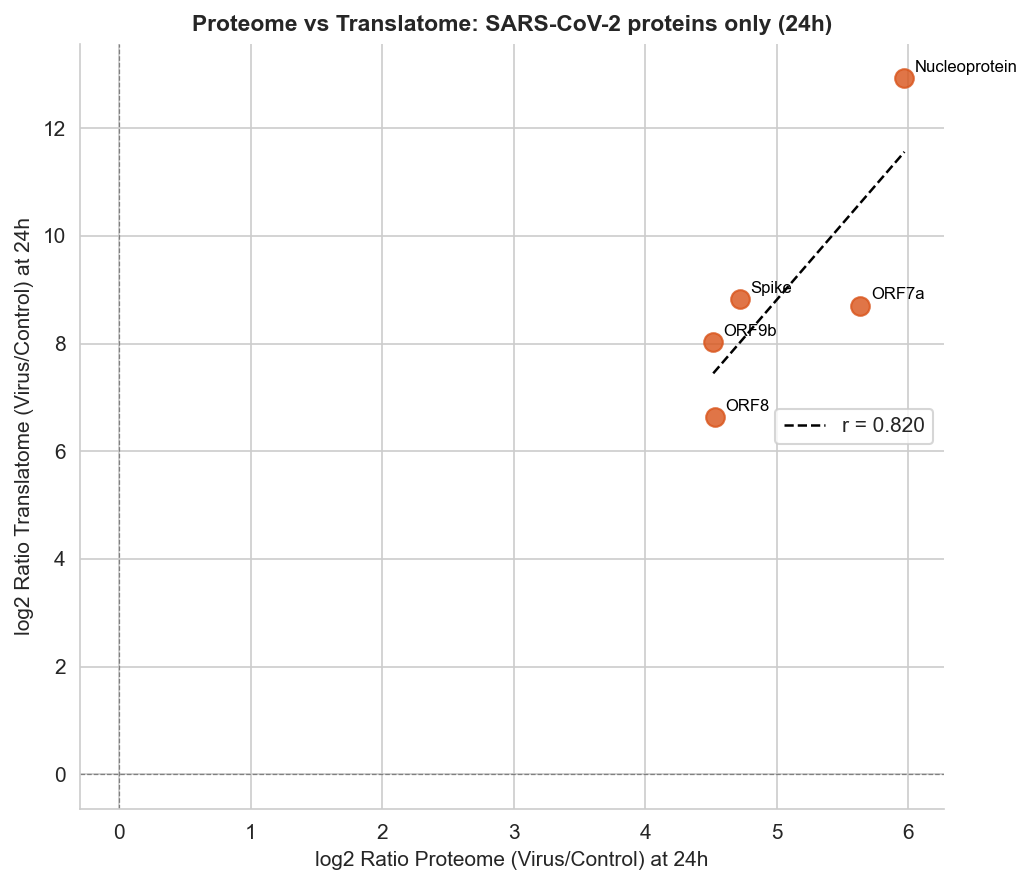

In [28]:
viral_combined = combined[combined['is_viral']].copy().replace(
    [np.inf, -np.inf], np.nan
).dropna(subset=['prot_ratio_24h', 'trans_ratio_24h'])

print(f"Viral proteins in both datasets: {len(viral_combined)}")

# Correlations at each timepoint
print("\nCorrelation for SARS-CoV-2 proteins only:")
for tp in timepoints:
    pc = f'prot_ratio_{tp}'
    tc = f'trans_ratio_{tp}'
    clean = viral_combined[[pc, tc]].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    if len(clean) >= 3:
        r, p = stats.pearsonr(clean[pc], clean[tc])
        print(f"  {tp:4s} — Pearson r = {r:.3f}  (n = {len(clean)} proteins)")
    else:
        print(f"  {tp:4s} — Not enough data points")

# Scatter plot — 24h only
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(viral_combined['prot_ratio_24h'],
           viral_combined['trans_ratio_24h'],
           color='#D95319', s=80, alpha=0.8, zorder=3)

# Label with full readable names
for _, row in viral_combined.iterrows():
    ax.annotate(
        row['Viral_short_name'],     # e.g. "Nucleoprotein", "Spike"
        xy=(row['prot_ratio_24h'], row['trans_ratio_24h']),
        xytext=(5, 3), textcoords='offset points',
        fontsize=8, color='black'
    )

# Regression line
if len(viral_combined) >= 2:
    m, b = np.polyfit(
        viral_combined['prot_ratio_24h'],
        viral_combined['trans_ratio_24h'], 1
    )
    x_range = np.linspace(
        viral_combined['prot_ratio_24h'].min(),
        viral_combined['prot_ratio_24h'].max(), 100
    )
    r_v, _ = stats.pearsonr(
        viral_combined['prot_ratio_24h'],
        viral_combined['trans_ratio_24h']
    )
    ax.plot(x_range, m * x_range + b,
            color='black', linewidth=1.2, linestyle='--',
            label=f'r = {r_v:.3f}')
    ax.legend(fontsize=10)

ax.axhline(y=0, color='grey', linewidth=0.6, linestyle='--')
ax.axvline(x=0, color='grey', linewidth=0.6, linestyle='--')
ax.set_xlabel('log2 Ratio Proteome (Virus/Control) at 24h', fontsize=10)
ax.set_ylabel('log2 Ratio Translatome (Virus/Control) at 24h', fontsize=10)
ax.set_title(
    'Proteome vs Translatome: SARS-CoV-2 proteins only (24h)',
    fontsize=11, fontweight='bold'
)
sns.despine()
plt.tight_layout()
plt.savefig('W11_P2_T6_viral_correlation.png', bbox_inches='tight')
plt.show()